# Multi-Series Demand Forecasting EDA

## Analysis Objectives
- **Data Quality Assessment**: Identify missing values, outliers, and data inconsistencies
- **Target Variable Analysis**: Understand demand quantity distribution and characteristics
- **Geographic Analysis**: Analyze demand patterns across different locations and regions
- **Time Series Analysis**: Examine temporal patterns, trends, and seasonality,
- **Forecasting Insights**: Assess complexity for multi-series forecasting models

---

In [ ]:
! pip install polars pandas numpy matplotlib seaborn openpyxl scipy pyarrow

: 

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import time
import os
import datetime as dt
import calendar
import re
import json

# Visualization
from PIL import Image
from html import unescape
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from IPython.display import Image, display


import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("Polars loaded successfully!")
print(f"Polars version: {pl.__version__}")

Polars loaded successfully!
Polars version: 1.35.2


In [3]:
! pip install chardet

In [4]:
import chardet

In [5]:
%matplotlib inline

### For all 60cols

In [ ]:
def load_data(file_path, sample_size=None):
    """
    Load CSV file for analysis selecting only important columns.
    """
    print(f"Loading CSV file with Polars: {file_path}")
    start_time = time.time()
    file_size = os.path.getsize(file_path) / (1024**3)  # GB
    print(f"File size: {file_size:.2f} GB")

    try:
        if sample_size:
            df = pl.read_csv(file_path, n_rows=sample_size)
            print(f"Loaded sample: {len(df)} rows")
        else:
            df = pl.read_csv(file_path, schema_overrides={"Associate Previous Project": pl.Utf8}, ignore_errors=True)
            print(f"Full dataset loaded: {len(df)} rows")

        load_time = time.time() - start_time
        print(f"Load time: {load_time:.2f} seconds")
        print(f"Speed: {len(df)/load_time:.0f} rows/second")
        
        return df

    except Exception as e:
        print(f"Error loading file: {e}")
        return None

# Load the data
FILE_PATH = os.path.join('data' ,'DFC_YTD.csv')

print("\nStarting data loading...")
df_YTD = load_data(FILE_PATH)

if df_YTD is not None:
    print(f"\nDataset Info:")
    print(f"  Shape: {df_YTD.shape}")
    print(f"  Columns: {df_YTD.columns}...")  # Show first 10 columns
    print(f"  Memory usage: {df_YTD.estimated_size() / (1024**2):.1f} MB")
else:
    print("Failed to load data")
    
# Load the data
FILE_PATH = os.path.join('data', 'DFC_MTD.csv')

print("\nStarting data loading...")
df_MTD = load_data(FILE_PATH)

if df_MTD is not None:
    print(f"\nDataset Info:")
    print(f"  Shape: {df_MTD.shape}")
    print(f"  Columns: {df_MTD.columns}")  # Show all columns since we filtered
    print(f"  Memory usage: {df_MTD.estimated_size() / (1024**2):.1f} MB")
else:
    print("Failed to load data")
    

# Align df_MTD to have all columns from df_YTD
df_MTD_aligned = df_MTD.select([
    pl.col(col) if col in df_MTD.columns else pl.lit(None).alias(col)
    for col in df_YTD.columns
])

# Cast all columns to Utf8 for both DataFrames
df_YTD = df_YTD.cast({col: pl.Utf8 for col in df_YTD.columns})
df_MTD_aligned = df_MTD_aligned.cast({col: pl.Utf8 for col in df_MTD_aligned.columns})

# Concatenate
df = pl.concat([df_YTD, df_MTD_aligned], how="vertical")
print(f"Combined shape: {df.shape}")

print(f"Combined DataFrame shape: {df.shape}")
print(f"Columns: {df.columns}")

columns_to_remove = [
    # Previously identified high-null columns
    "SBU2", "Associate Hired Grade", "SO Submission Date 2", "Offer Created Date",
    "Offer Extended Date", "Available positions in RR", "Offer Status", "Offer Sub Status",
    "No Of Offers", "Job Opening Status", "Recruiter ID", "Recruiter Name",
    "Assignment Start Date", "Cancelled BY ID", "Preferred Location 1", "Preferred Location 2",
    "Sub Track", "Sub Track Description", "Technical Skills Desired", "Functional Skills",
    "Additional Skills", "RLC", "Domain Skill Layer 1", "Domain Skill Layer 2",
    "Domain Skill Layer 3", "Revenue Loss Category", "Staffing Team Member ",
    "Staffing Team Lead", "TMP SO Status", "Primary Skill Set", "Expected Date Of Joining",
    "Replaced Associate", "OE Approval Comments", "TSC Approval Comments",
    "Secondary State tag", "Job Description", "Revenue", "MU Priority", "iRise Status",
    "IJM Allocation", "Deflag MFR Date", "Approver ID", "Approver Name",
    "Project Classification", "Assignment Staging Date", "Order Description", "Data/Voice",

    # Additional ones
    "Action Date", "Subcontractor Allowed by Customer", "Interview Required by Customer",
    "When Flagged for Recruitment", "cancellation_comments", "Billability Start date",
    "TAT(Flag dt to Interview dt)", "TAT(Int to Offer creation)",
    "TAT(Offer create to Offer approve)", "TAT(Offer Apprvd to Offer Extnd)",
    "TAT(Offer extnd -EDOJ)", "TAT(Exp DOJ- DOJ)", "Cancellation Ageing", "Open SO Ageing",
    "RR Ageing", "CCA Service Line", "CCA Service Line Description", "Track",
    "Track Description", "Demand Role Code", "Demand Role Description",
     "Leadership and Prof. Dev. Comp", "Skill Family", "RSC1",
    "Requirement type", "Customer Bill rate", "Bill rate currency", "OE Approval flag",
    "OE Approver Date", "TSC Approval flag", "TSC Approver ID", "TSC Approver Date",
    "status_remark", "Opportunity Status", "greenchannel", "Forecast Category",
    "Win Probability", "Estimated Deal close date", "Actual Expected Revenue Start date",
    "Opportunity Owner", "OwnerID", "Recommended for Hiring By", "Recommended for Hiring On",
    "SO Priority", "Service Description", "Cluster Description", "Demand Unit Description",
    "Is this demand open for all Cognizant locations across India?",
    "Skills(Anchor/Supplementary)", "SO Work Model",
    "SoStatus", "Probable Fullfilment Date", "Customer Project"
]
    
# Define the function
def clean_data_and_save(df, columns_to_remove=None):
    print('Data Cleaning Process')
    print('-' * 40)
    
    initial_shape = df.shape
    print(f'Initial shape: {initial_shape[0]:,} rows × {initial_shape[1]} columns')
    
    # Drop specified columns first
    if columns_to_remove:
        cols_to_drop = [col for col in columns_to_remove if col in df.columns]
        df = df.drop(cols_to_drop)
        print(f'Removed {len(cols_to_drop)} columns')
    
    print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
    return df

print(f'shape before cleaning: {df.shape}')
df = clean_data_and_save(df, columns_to_remove)

print('Cleaned DataFrame:')
print('shape:', df.shape)
print('columns being included: ', df.columns)
print(df.head())


# SO Type STA
FILTERS = {
    'SO TYPE': ['STA'],
    'Project Type': ['EXTN', 'EXANT'],
    'Practice Area': ['Digital Engineering'], 
    'ServiceLine': [ 'SOFTWARE & PLATFORM ENGINEERING'],
    'Market': ['Americas', 'EMEA'], #reduce to one of the markets (America) , 'EMEA'
    'Project Billability Type': ['BFD', 'BTB', 'BTM'],
    'Cancellation Reason' :[
                            "NA",
                            "Project/Requirement postponed or on hold by client",
                            "Opportunity Lost",
                            "Alternate Transactional SO created",
                            "Replace by Internal Fulfilment - Allocation",
                            "Requirement staffed by client/other vendor",
                            "SO Criticality Change",
                            "Project Preponement",
                            "Staffing Challenge",
                            "Labor Market Testing Unsuccessful"
                        ],

}

def apply_business_filters(dataframe, filters_dict):
    """
    Apply predefined business filters to DataFrame, keeping only matching rows.
    """
    # Start with the original dataframe
    filtered_df = dataframe.clone()
    
    # Apply each filter sequentially
    for column_name, allowed_values in filters_dict.items():
        # Ensure column exists in dataframe
        if column_name in filtered_df.columns:
            # Filter to keep only rows where column value is in allowed_values
            filtered_df = filtered_df.filter(
                filtered_df[column_name].is_in(allowed_values)
            )
        else:
            print(f"Warning: Column '{column_name}' not found in dataframe")
    
    return filtered_df


df = apply_business_filters(df, FILTERS)

# df.write_csv(os.path.join('data' ,'cleaned_data2.csv'))

print(f"Original rows: {len(df)}, Filtered rows: {len(df)}")

def combine_grades(df, col='SO GRADE', exclude_vals=('Admin Staff',)):
    """Merge grade categories and exclude specified values"""
    # Prepare case-insensitive matching
    src = pl.col(col).cast(pl.Utf8)
    upper = src.str.to_uppercase()

    # Map (PT, PAT, PA, P, Admin Staff) -> LM
    lm_set = ['PT', 'PAT', 'PA', 'P']
    combined = pl.when(upper.is_in(lm_set)).then(pl.lit('GenC')).otherwise(src)


    # Exclude rows matching exclude_vals (case-insensitive)
    excl_upper = [v.upper() for v in exclude_vals]
    df = df.filter(~upper.is_in(excl_upper))

    # Write merged grades
    df = df.with_columns(combined.alias(col))
    return df

print("No. of categories in SO Grade before combining:", df.select(pl.col('SO GRADE').n_unique()).item())
# df = combine_grades(df)

print("No. of categories in SO Grade after combining:", df.select(pl.col('SO GRADE').n_unique()).item())
print("list of SO GRADES", df.select(pl.col('SO GRADE').unique().sort()))


def clean_and_standardize_dates(df):
    # 1) Identify date-like columns, excluding 'Fulfilment/Cancellation Month'
    patterns = [r"date", r"time", r"month", r"day"]
    date_cols = [c for c in df.columns if any(re.search(p, c, re.IGNORECASE) for p in patterns)]
    date_cols = [c for c in date_cols if c != "Fulfilment/Cancellation Month"]

    print(f"[INFO] Date columns (excluding Fulfilment): {date_cols}")
    print(f"[INFO] Original shape: {df.shape}")

    # Common formats to try
    fmts = [
        "%Y-%m-%d", "%m-%d-%Y",
        "%Y/%m/%d", "%m/%d/%Y",
        "%d-%b-%Y", "%d-%b-%y"
    ]

    for col in date_cols:
        print(f"\n[STEP] Processing: {col}")
        parsed = pl.lit(None, dtype=pl.Date)
        
        for i, fmt in enumerate(fmts, start=1):
            attempt = pl.col(col).cast(pl.Utf8).str.strptime(pl.Date, fmt, strict=False)
            parsed = parsed.fill_null(attempt)
            count = df.select(attempt.is_not_null().sum()).item()
            print(f"  - Try {i}: {fmt} -> parsed {count}")

        df = df.with_columns(parsed.alias(col))
        nulls = df.select(pl.col(col).is_null().sum()).item()
        sample = df.select(pl.col(col).dt.strftime("%Y-%m-%d")).head(3).to_dict(as_series=False)[col]
        print(f"  - Nulls after parsing: {nulls}")
        print(f"  - Sample (ISO): {sample}")

    print(f"\n[INFO] Final shape: {df.shape}")
    print("[INFO] All date columns are pl.Date. CSV will be written in ISO format.")
    return df

# Usage
df = clean_and_standardize_dates(df)


def null_data_analysis(df):
    """Analyze null values and return rows with nulls"""
    total_rows = df.height

    # Compute null counts efficiently
    null_counts = df.null_count().row(0)

    # Print summary only for columns with nulls
    for col, count in zip(df.columns, null_counts):
        if count > 0:
            print(f"{col}: {count}/{total_rows} rows have nulls")
    
    return


null_data_analysis(df)

print(f"Shape before dropping nulls: {df.shape}")


df = df.drop_nulls()

print(f"Shape after dropping nulls: {df.shape}")

df.write_csv(os.path.join('data' ,'cleaned_data3_60cols.csv'))





Starting data loading...
Loading CSV file with Polars: data\DFC_YTD.csv
File size: 0.85 GB
Full dataset loaded: 712983 rows
Load time: 3.58 seconds
Speed: 199383 rows/second

Dataset Info:
  Shape: (712983, 160)
  Columns: ['SO Line Status', 'Unique ID', 'Owning Organization', 'Pool ID', 'Pool Name', 'Department', 'Vertical', 'Practice', 'SubVertical', 'SubPractice', 'BU', 'BusinessUnit Desc', 'SBU1', 'SBU2', 'Account ID', 'Account Name', 'Parent Customer', 'Parent Customer ID', 'Project ID', 'Project Name', 'Project Type', 'Project Billability Type', 'Associate Hired Grade', 'Quantity', 'Action Date', 'SO Submission Date', 'SO Submission Date 2', 'Offer Created Date', 'Offer Extended Date', 'Available positions in RR', 'Offer Status', 'Offer Sub Status', 'No Of Offers', 'Job Opening Status', 'Recruiter ID', 'Recruiter Name', 'Subcontractor Allowed by Customer', 'Interview Required by Customer', 'T&MRateCard', 'Assignment Start Date', 'Job Code', 'Flagged for Recruitment', 'When Flagg

### Data Loading Section

#### Historical Data

In [ ]:
# Columns to load
columns_imp = [
    'SO Line Status', 'Unique ID', 'Vertical', 'Practice', 'SubVertical', 'SubPractice',
    'BU', 'Parent Customer', 'Project Type', 'Project Billability Type', 'Quantity',
    'SO Submission Date', 'Cancellation Reason', 'Off/ On', 'Geography', 'Country',
    'City', 'Fulfilment/Cancellation Month', 'Requirement Start Date', 'Market',
    'SO TYPE', 'SO GRADE', 'Technical Skills Required', 'Requirement type',
    'Practice Area', 'ServiceLine', 'Original Requirement Start date', 
    'Revenue potential',
    "SBU1",
    "Account ID",
    "Account Name",
    "Parent Customer ID", "Market Unit",
    # 'Project ID', 'Demand Role Code', 'Demand Role Description', 'Track', 'Track Description',
    # 'Associate Fulfilled against the SO', 'Associate Hired Grade', 'Sub Track', 'Sub Track Description'
]

def load_data(file_path, sample_size=None):
    """
    Load CSV file for analysis selecting only important columns.
    """
    print(f"Loading CSV file with Polars: {file_path}")
    start_time = time.time()
    file_size = os.path.getsize(file_path) / (1024**3)  # GB
    print(f"File size: {file_size:.2f} GB")

    try:
        if sample_size:
            df = pl.read_csv(file_path, columns=columns_imp, n_rows=sample_size)
            print(f"Loaded sample: {len(df)} rows")
        else:
            df = pl.read_csv(file_path, columns=columns_imp)
            print(f"Full dataset loaded: {len(df)} rows")

        load_time = time.time() - start_time
        print(f"Load time: {load_time:.2f} seconds")
        print(f"Speed: {len(df)/load_time:.0f} rows/second")
        
        return df

    except Exception as e:
        print(f"Error loading file: {e}")
        return None

# Load the data
FILE_PATH_2025 = os.path.join('data' ,'DFC_YTD_2025.csv')
FILE_PATH_2024 = os.path.join('data' ,'DFC_YTD_2024-utf.csv')
FILE_PATH_2023 = os.path.join('data' ,'DFC_YTD_2023-utf.csv')

for path in [FILE_PATH_2025, FILE_PATH_2024, FILE_PATH_2023]:
    exists = os.path.exists(path)
    size = os.path.getsize(path) if exists else "N/A"
    print(f"{path}: Exists={exists}, Size={size}")

print("\nStarting data loading...")
df_YTD_2025 = load_data(FILE_PATH_2025)
df_YTD_2024 = load_data(FILE_PATH_2024)
df_YTD_2023 = load_data(FILE_PATH_2023)

df_YTD = pl.concat([df_YTD_2023, df_YTD_2024, df_YTD_2025])

if df_YTD is not None:
    print(f"\nDataset Info:")
    print(f"  Shape: {df_YTD.shape}")
    print(f"  Columns: {df_YTD.columns}...")  # Show first 10 columns
    print(f"  Memory usage: {df_YTD.estimated_size() / (1024**2):.1f} MB")
else:
    print("Failed to load data")

data\DFC_YTD_2025.csv: Exists=True, Size=941643743
data\DFC_YTD_2024-utf.csv: Exists=True, Size=799597824
data\DFC_YTD_2023-utf.csv: Exists=True, Size=699895003

Starting data loading...
Loading CSV file with Polars: data\DFC_YTD_2025.csv
File size: 0.88 GB
Full dataset loaded: 722763 rows
Load time: 1.11 seconds
Speed: 653752 rows/second
Loading CSV file with Polars: data\DFC_YTD_2024-utf.csv
File size: 0.74 GB
Full dataset loaded: 655857 rows
Load time: 1.01 seconds
Speed: 649447 rows/second
Loading CSV file with Polars: data\DFC_YTD_2023-utf.csv
File size: 0.65 GB
Full dataset loaded: 651444 rows
Load time: 0.87 seconds
Speed: 750160 rows/second

Dataset Info:
  Shape: (2030064, 32)
  Columns: ['SO Line Status', 'Unique ID', 'Vertical', 'Practice', 'SubVertical', 'SubPractice', 'BU', 'SBU1', 'Account ID', 'Account Name', 'Parent Customer', 'Parent Customer ID', 'Project Type', 'Project Billability Type', 'Quantity', 'SO Submission Date', 'Cancellation Reason', 'Off/ On', 'Geography'

#### Open Demand

In [40]:
# Load the data
FILE_PATH = os.path.join('data', 'DFC_MTD_2025.csv')

print("\nStarting data loading...")
df_MTD = load_data(FILE_PATH)

if df_MTD is not None:
    print(f"\nDataset Info:")
    print(f"  Shape: {df_MTD.shape}")
    print(f"  Columns: {df_MTD.columns}")  # Show all columns since we filtered
    print(f"  Memory usage: {df_MTD.estimated_size() / (1024**2):.1f} MB")
else:
    print("Failed to load data")



Starting data loading...
Loading CSV file with Polars: data\DFC_MTD_2025.csv
File size: 0.11 GB
Full dataset loaded: 65181 rows
Load time: 0.14 seconds
Speed: 455197 rows/second

Dataset Info:
  Shape: (65181, 32)
  Columns: ['SO Line Status', 'Unique ID', 'Vertical', 'Practice', 'SubVertical', 'SubPractice', 'BU', 'SBU1', 'Account ID', 'Account Name', 'Parent Customer', 'Parent Customer ID', 'Project Type', 'Project Billability Type', 'Quantity', 'SO Submission Date', 'Cancellation Reason', 'Off/ On', 'Geography', 'Country', 'City', 'Fulfilment/Cancellation Month', 'Requirement Start Date', 'Market', 'SO TYPE', 'SO GRADE', 'Technical Skills Required', 'Requirement type', 'Revenue potential', 'Practice Area', 'ServiceLine', 'Original Requirement Start date']
  Memory usage: 22.6 MB


#### Combine Open Demands with Historical (MTD + YTD)

In [41]:

#Combine YTD and MTD data
df = pl.concat([df_YTD, df_MTD], how="vertical")

print(f"Combined DataFrame shape: {df.shape}")
print(f"Columns: {df.columns}")


Combined DataFrame shape: (2095245, 32)
Columns: ['SO Line Status', 'Unique ID', 'Vertical', 'Practice', 'SubVertical', 'SubPractice', 'BU', 'SBU1', 'Account ID', 'Account Name', 'Parent Customer', 'Parent Customer ID', 'Project Type', 'Project Billability Type', 'Quantity', 'SO Submission Date', 'Cancellation Reason', 'Off/ On', 'Geography', 'Country', 'City', 'Fulfilment/Cancellation Month', 'Requirement Start Date', 'Market', 'SO TYPE', 'SO GRADE', 'Technical Skills Required', 'Requirement type', 'Revenue potential', 'Practice Area', 'ServiceLine', 'Original Requirement Start date']


### Data Cleaning Function
#### Function to clean data by removing empty columns and specified columns, then save to CSV


In [ ]:
columns_to_remove = [
    "Department",
    "BusinessUnit Desc",
    # "SBU1",
    "SBU2",
    # "Account ID",
    # "Account Name",
    # "Parent Customer ID",
    "Project ID",
    "Project Name",
    "Action Date",
    "SO Submission Date 2",
    "Offer Created Date",
    "Offer Extended Date",
    "Available positions in RR",
    "Offer Status",
    "Offer Sub Status",
    "No Of Offers",
    "Job Opening Status",
    "Recruiter ID",
    "Recruiter Name",
    "Subcontractor Allowed by Customer",
    "Interview Required by Customer",
    "T&MRateCard",
    "Assignment Start Date",
    "Job Code",
    "Preferred Location 1",
    "Preferred Location 2",
    "Requirement End Date",
    "Additional Revenue",
    "Billability Start date",
    "INTERNAL FULFILMENT-TAT",
    "EXTERNAL FULFILMENT- WFM -TAT",
    "EXTERNAL FULFILMENT- TAG -TAT",
    "TAT(Flag dt to Interview dt)",
    "TAT(Int to Offer creation)",
    "TAT(Offer create to Offer approve)",
    "TAT(Offer Apprvd to Offer Extnd)",
    "TAT(Offer extnd -EDOJ)",
    "TAT(Exp DOJ- DOJ)",
    "Source category",
    "Cancellation Ageing",
    "Open SO Ageing",
    "RR Ageing",
    "Open SO Ageing range",
    "RR Ageing range",
    "CCA Service Line",
    "CCA Service Line Description",
    "Track",
    "Track Description",
    "Sub Track",
    "Sub Track Description",
    "Demand Role Code",
    "Demand Role Description",
    "Leadership and Prof. Dev. Comp",
    "Additional Skills",
    "Skill Family",
    "RLC",
    "RSC1",
    "Domain Skill Layer 1",
    "Domain Skill Layer 2",
    "Domain Skill Layer 3",

    # "Revenue potential",
    "Revenue Loss Category",
    "Staffing Team Member",
    "Staffing Team Lead",
    "SoStatus",
    "TMP SO Status",
    "Probable Fullfilment Date",
    "Open Trained Associate",
    "Primary Skill Set",
    "Expected Date Of Joining",
    "Replaced Associate",
    "Customer Bill rate",
    "Bill rate currency",
    "Customer Profitability",
    "OE Approval flag",
    "OE Approver Date",
    "OE Approval Comments",
    "TSC Approval flag",
    "TSC Approver ID",
    "TSC Approver Date",
    "TSC Approval Comments",
    "Customer Project",
    "Primary State tag",
    "Secondary State tag",
    "status_remark",
    "Opportunity Status",
    "Job Description",
    "Revenue",
    "greenchannel",
    "Forecast Category",
    "Win Probability",
    "Estimated Deal close date",
    "Actual Expected Revenue Start date",
    "Opportunity Owner",
    "OwnerID",
    "Recommended for Hiring By",
    "Recommended for Hiring On",
    "SO Priority",
    "MU Priority",
    "iRise Status",
    "PE Flagged",
    "IJM Allocation",
    "Deflag MFR",
    "Deflag MFR Date",
    "Original TAT",
    "Approver ID",
    "Approver Name",
    "Delivery/Non-Delivery",
    "Project Classification",
    "Service Description",
    "Cluster Description",
    "Demand Unit Description",
    "Is this demand open for all Cognizant locations across India?",
    "Skills(Anchor/Supplementary)",
    "Assignment Staging Date",
    "SO Work Model",
    "State",
    "Order Description",
    "Data/Voice",
    "Active RR Status",
    "Staffing Team Member ",
    "SO Billability",
    "Cancelled BY ID",
    # "Cancellation Reason",
    "cancellation_comments",
    "Owning Organization",
    "Pool ID",
    "Pool Name",
    "Associate Hired Grade",
    "Flagged for Recruitment",
    "When Flagged for Recruitment",
    
    #"Market Unit",
    "Technical Skills Desired",
    "Functional Skills",
    "Original Requirement Start date"
        
]





In [43]:
# Define the function
def clean_data_and_save(df, columns_to_ignore=None):
    print('Data Cleaning Process')
    print('-' * 40)
    
    initial_shape = df.shape
    print(f'Initial shape: {initial_shape[0]:,} rows × {initial_shape[1]} columns')
    
    # Initialize list for removed columns
    removed_columns = []
    
    # Find fully empty columns (all null values)
    null_counts = df.null_count()
    empty_columns = []
    
    for col in df.columns:
        null_count = null_counts[col].item()
        if null_count == len(df):
            empty_columns.append(col)
    
    if empty_columns:
        removed_columns.extend(empty_columns)
        print(f'Fully empty columns removed ({len(empty_columns)}):')
        for col in empty_columns:
            print(f'  - {col}')
    else:
        print('No fully empty columns found')
    
    # Remove specified columns to ignore
    if columns_to_ignore:
        ignored_columns = [col for col in columns_to_ignore if col in df.columns]
        if ignored_columns:
            removed_columns.extend(ignored_columns)
            print(f'\nSpecified columns removed ({len(ignored_columns)}):')
            # for col in ignored_columns:
            #     print(f'  - {col}')
        else:
            print('\nNo specified columns found to remove')
    
    os.makedirs('data', exist_ok=True)
    out = os.path.join('data','cleaned_data1.csv')
    # Remove all identified columns
    if removed_columns:
        df_cleaned = df.drop(removed_columns)
        print(f'\nTotal columns removed: {len(removed_columns)}')
        print(f'Final shape: {df_cleaned.shape[0]:,} rows × {df_cleaned.shape[1]} columns')
        
        # Save to CSV
        df_cleaned.write_csv(out)
        print(f'\nCleaned data saved to: cleaned_data1.csv')
        
        return df_cleaned
    else:
        print('\nNo columns to remove')
        print(f'Final shape: {initial_shape[0]:,} rows × {initial_shape[1]} columns')
        
        # Save to CSV even if no columns removed
        df.write_csv(out)
        print(f'\nData saved to: cleaned_data1.csv')
        
        return df

# Test the function
print('Testing function with columns_to_ignore:')


df = clean_data_and_save(df, columns_to_remove)

print('Cleaned DataFrame:')
print('shape:', df.shape)
print('columns being included: ', df.columns)
print(df.head())


Testing function with columns_to_ignore:
Data Cleaning Process
----------------------------------------
Initial shape: 2,095,245 rows × 32 columns
No fully empty columns found

Specified columns removed (1):

Total columns removed: 1
Final shape: 2,095,245 rows × 31 columns

Cleaned data saved to: cleaned_data1.csv
Cleaned DataFrame:
shape: (2095245, 31)
columns being included:  ['SO Line Status', 'Unique ID', 'Vertical', 'Practice', 'SubVertical', 'SubPractice', 'BU', 'SBU1', 'Account ID', 'Account Name', 'Parent Customer', 'Parent Customer ID', 'Project Type', 'Project Billability Type', 'Quantity', 'SO Submission Date', 'Cancellation Reason', 'Off/ On', 'Geography', 'Country', 'City', 'Fulfilment/Cancellation Month', 'Requirement Start Date', 'Market', 'SO TYPE', 'SO GRADE', 'Technical Skills Required', 'Requirement type', 'Revenue potential', 'Practice Area', 'ServiceLine']
shape: (5, 31)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬─────

### Data Filtering
#### Applying filters to the data and only narrowing it down to required types.


In [ ]:
# SO Type STA
FILTERS = {
    'SO TYPE': ['STA'],
    'Project Type': ['EXTN', 'EXANT'],
    'Practice Area': ['Digital Engineering'], 
    'ServiceLine': ['SOFTWARE & PLATFORM ENGINEERING'], #'ENTERPRISE PLATFORM SERVICES', 
    'Market': ['Americas', 'EMEA', 'GGM'], #reduce to one of the markets (America) , 'EMEA'
    'Project Billability Type': ['BFD', 'BTB', 'BTM'],
    'Cancellation Reason' :[
                            "NA",
                            "Project/Requirement postponed or on hold by client",
                            "Opportunity Lost",
                            "Alternate Transactional SO created",
                            "Replace by Internal Fulfilment - Allocation",
                            "Requirement staffed by client/other vendor",
                            "SO Criticality Change",
                            "Project Preponement",
                            "Staffing Challenge",
                            "Labor Market Testing Unsuccessful"
                        ],

}

In [45]:
def top_practice_areas_with_counts(df, filters, n=10):
    # apply filters except Practice Area
    for col, vals in filters.items():
        if col != 'Practice Area' and col in df.columns:
            df = df.filter(pl.col(col).is_in(vals))
    # return top N (area, count)
    out = (
        df.group_by('Practice Area')
          .count()
          .sort('count', descending=True)
          .head(n)
    )
    return list(zip(out['Practice Area'].to_list(), out['count'].to_list()))

top_practice_areas = top_practice_areas_with_counts(df, FILTERS)
print(top_practice_areas)

top_practice = top_practice_areas[0][0]  # Get the top practice area name
print("Top Practice Area:", top_practice)



[('Digital Engineering', 86828), ('ADM', 61073), ('QEA', 59616), ('QE & A', 6494), ('DX Digital Experience', 4334), ('Digital Experience', 658), ('S&PE Central', 281)]
Top Practice Area: Digital Engineering


In [46]:
# FILTERS['Practice Area'] = [top_practice]
# print("Updated FILTERS:", json.dumps(FILTERS, indent=4))

In [47]:
def apply_business_filters(dataframe, filters_dict):
    """
    Apply predefined business filters to DataFrame, keeping only matching rows.
    """
    # Start with the original dataframe
    filtered_df = dataframe.clone()
    
    # Apply each filter sequentially
    for column_name, allowed_values in filters_dict.items():
        # Ensure column exists in dataframe
        if column_name in filtered_df.columns:
            # Filter to keep only rows where column value is in allowed_values
            filtered_df = filtered_df.filter(
                filtered_df[column_name].is_in(allowed_values)
            )
        else:
            print(f"Warning: Column '{column_name}' not found in dataframe")
    
    return filtered_df


df = apply_business_filters(df, FILTERS)

df.write_csv(os.path.join('data' ,'cleaned_data2.csv'))

print(f"Original rows: {len(df)}, Filtered rows: {len(df)}")

Original rows: 86828, Filtered rows: 86828


### Grades Combining
#### ( PT, PAT, PA, P) --> GenC (Lower Management) && Exclude cont

In [ ]:
def combine_grades(df, col='SO GRADE', exclude_vals=('cont',)):
    """Merge grade categories and exclude specified values"""
    # Prepare case-insensitive matching
    src = pl.col(col).cast(pl.Utf8)
    upper = src.str.to_uppercase()

    # Map (PT, PAT, PA, P) -> LM
    lm_set = ['PT', 'PAT', 'PA', 'P']
    combined = pl.when(upper.is_in(lm_set)).then(pl.lit('GenC')).otherwise(src)


    # Exclude rows matching exclude_vals (case-insensitive)
    excl_upper = [v.upper() for v in exclude_vals]
    df = df.filter(~upper.is_in(excl_upper))

    # Write merged grades
    df = df.with_columns(combined.alias(col))
    return df

print("No. of categories in SO Grade before combining:", df.select(pl.col('SO GRADE').n_unique()).item())
df = combine_grades(df)

print("No. of categories in SO Grade after combining:", df.select(pl.col('SO GRADE').n_unique()).item())
print("list of SO GRADES", df.select(pl.col('SO GRADE').unique().sort()))

No. of categories in SO Grade before combining: 16
No. of categories in SO Grade after combining: 11
list of SO GRADES shape: (11, 1)
┌─────────────┐
│ SO GRADE    │
│ ---         │
│ str         │
╞═════════════╡
│ A           │
│ AD          │
│ AVP         │
│ Admin Staff │
│ D           │
│ …           │
│ M           │
│ SA          │
│ SM          │
│ Sr. Dir.    │
│ VP          │
└─────────────┘


### Date Cleaning

In [ ]:
def clean_and_standardize_dates(df):
    # 1) Identify date-like columns, excluding 'Fulfilment/Cancellation Month'
    patterns = [r"date", r"time", r"month", r"day"]
    date_cols = [c for c in df.columns if any(re.search(p, c, re.IGNORECASE) for p in patterns)]
    date_cols = [c for c in date_cols if c != "Fulfilment/Cancellation Month"]

    print(f"[INFO] Date columns (excluding Fulfilment): {date_cols}")
    print(f"[INFO] Original shape: {df.shape}")

    # Common formats to try
    fmts = [
        "%Y-%m-%d", "%m-%d-%Y",
        "%Y/%m/%d", "%m/%d/%Y",
        "%d-%b-%Y", "%d-%b-%y"
    ]

    for col in date_cols:
        print(f"\n[STEP] Processing: {col}")
        parsed = pl.lit(None, dtype=pl.Date)
        
        for i, fmt in enumerate(fmts, start=1):
            attempt = pl.col(col).cast(pl.Utf8).str.strptime(pl.Date, fmt, strict=False)
            parsed = parsed.fill_null(attempt)
            count = df.select(attempt.is_not_null().sum()).item()
            print(f"  - Try {i}: {fmt} -> parsed {count}")

        df = df.with_columns(parsed.alias(col))
        nulls = df.select(pl.col(col).is_null().sum()).item()
        sample = df.select(pl.col(col).dt.strftime("%Y-%m-%d")).head(3).to_dict(as_series=False)[col]
        print(f"  - Nulls after parsing: {nulls}")
        print(f"  - Sample (ISO): {sample}")

    print(f"\n[INFO] Final shape: {df.shape}")
    print("[INFO] All date columns are pl.Date. CSV will be written in ISO format.")
    return df

# Usage
print(df.shape)
df = clean_and_standardize_dates(df)


(79481, 31)
[INFO] Date columns (excluding Fulfilment): ['SO Submission Date', 'Requirement Start Date']
[INFO] Original shape: (79481, 31)

[STEP] Processing: SO Submission Date
  - Try 1: %Y-%m-%d -> parsed 0
  - Try 2: %m-%d-%Y -> parsed 32004
  - Try 3: %Y/%m/%d -> parsed 0
  - Try 4: %m/%d/%Y -> parsed 47477
  - Try 5: %d-%b-%Y -> parsed 0
  - Try 6: %d-%b-%y -> parsed 0
  - Nulls after parsing: 0
  - Sample (ISO): ['2023-07-17', '2023-01-16', '2023-09-13']

[STEP] Processing: Requirement Start Date
  - Try 1: %Y-%m-%d -> parsed 0
  - Try 2: %m-%d-%Y -> parsed 30201
  - Try 3: %Y/%m/%d -> parsed 0
  - Try 4: %m/%d/%Y -> parsed 49280
  - Try 5: %d-%b-%Y -> parsed 0
  - Try 6: %d-%b-%y -> parsed 0
  - Nulls after parsing: 0
  - Sample (ISO): ['2023-08-20', '2023-02-27', '2023-10-31']

[INFO] Final shape: (79481, 31)
[INFO] All date columns are pl.Date. CSV will be written in ISO format.


### Null Data Cleaning and Analysis

In [50]:
def null_data_analysis(df):
    """Analyze null values and return rows with nulls"""
    total_rows = df.height

    # Compute null counts efficiently
    null_counts = df.null_count().row(0)

    # Print summary only for columns with nulls
    for col, count in zip(df.columns, null_counts):
        if count > 0:
            print(f"{col}: {count}/{total_rows} rows have nulls")
    
    return


null_data_analysis(df)

print(f"Shape before dropping nulls: {df.shape}")


df = df.drop_nulls()

print(f"Shape after dropping nulls: {df.shape}")

df.write_csv(os.path.join('data' ,'cleaned_data3.csv'))


Technical Skills Required: 619/79481 rows have nulls
Requirement type: 21/79481 rows have nulls
Revenue potential: 2/79481 rows have nulls
Shape before dropping nulls: (79481, 31)
Shape after dropping nulls: (78839, 31)


### Cancellation Counts

In [51]:

counts = (df.group_by("Cancellation Reason").len().sort("len", descending=True))

reason_counts = dict(zip(counts["Cancellation Reason"].to_list(), counts["len"].to_list()))
print(json.dumps(reason_counts, indent=2))


{
  "NA": 43844,
  "Project/Requirement postponed or on hold by client": 28746,
  "Opportunity Lost": 1469,
  "Alternate Transactional SO created": 1403,
  "Requirement staffed by client/other vendor": 1140,
  "Replace by Internal Fulfilment - Allocation": 1076,
  "Project Preponement": 591,
  "SO Criticality Change": 430,
  "Staffing Challenge": 134,
  "Labor Market Testing Unsuccessful": 6
}


### Data Overview Section
#### This section provides comprehensive data overview and quality assessment

In [52]:
! pip install pyarrow

In [53]:
def fast_data_overview(df):
    """
    Perform comprehensive data overview and quality assessment.

    Returns:
        list: List of missing data statistics
    """
    
    print("=" * 60)
    print(" COMPREHENSIVE DATA OVERVIEW")
    print("=" * 60)
    
    # Basic info
    print(f" Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # Data types
    schema = df.schema
    dtype_counts = {}
    for col, dtype in schema.items():
        dtype_str = str(dtype)
        dtype_counts[dtype_str] = dtype_counts.get(dtype_str, 0) + 1
    
    print(f"\n  Data Types:")
    for dtype, count in dtype_counts.items():
        print(f"  {dtype}: {count} columns")
    
    # Missing values analysis - FAST!
    print(f"\n Missing Values:")
    null_counts = df.null_count()
    
    missing_data = []
    for col in df.columns:
        null_count = null_counts[col]  # This is a Series
        null_count_scalar = null_count.item()  # Extract scalar value
        if null_count_scalar > 0:  # Use the scalar for comparison
            pct = (null_count_scalar / len(df)) * 100
            missing_data.append((col, null_count_scalar, pct))
    
    missing_data.sort(key=lambda x: x[2], reverse=True)
    
    if missing_data:
        for col, count, pct in missing_data[:15]:  # Top 15
            print(f"  {col:25} {count:>8,} ({pct:>5.1f}%)")
    else:
        print("  None found!")
    
    # Target variable analysis
    if 'Quantity' in df.columns:
        qty_stats = df.select('Quantity').to_pandas()['Quantity'].describe()
        print(f"\nTarget Variable (Quantity):")
        print(f"  Mean: {qty_stats['mean']:.2f}")
        print(f"  Median: {qty_stats['50%']:.2f}")
        print(f"  Std: {qty_stats['std']:.2f}")
        print(f"  Min: {qty_stats['min']:.0f}")
        print(f"  Max: {qty_stats['max']:.0f}")
        
        zeros = (df.select(pl.col('Quantity') == 0).sum().item())
        print(f"  Zeros: {zeros:,} ({zeros/len(df)*100:.1f}%)")
    
    return missing_data

# Run fast overview
if df is not None:
    missing_overview = fast_data_overview(df)

 COMPREHENSIVE DATA OVERVIEW
 Shape: 78,839 rows × 31 columns

  Data Types:
  String: 26 columns
  Int64: 3 columns
  Date: 2 columns

 Missing Values:
  None found!

Target Variable (Quantity):
  Mean: 1.00
  Median: 1.00
  Std: 0.00
  Min: 1
  Max: 1
  Zeros: 0 (0.0%)


### Target Variable Analysis Section
#### This section analyzes the target variable (demand quantity)



 TARGET VARIABLE ANALYSIS
----------------------------------------
Mean: 1.00
Median: 1.00
Std: 0.00
Skewness: 0.000
Kurtosis: 0.000


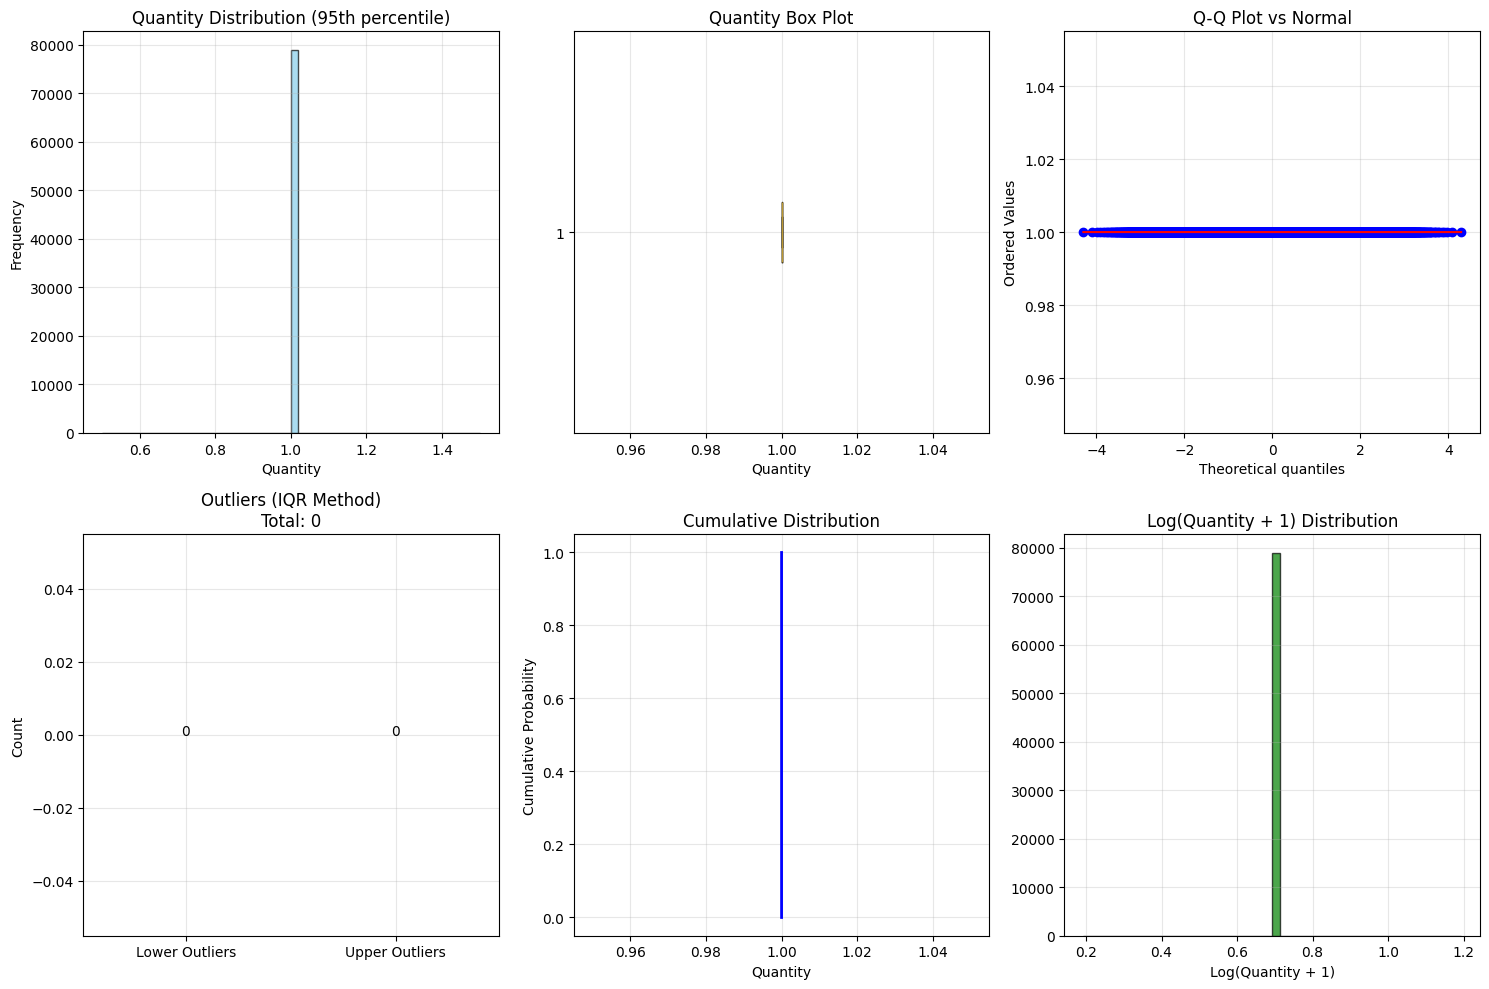


 Outlier Summary:
  IQR Range: [1.0, 1.0]
  Lower outliers: 0
  Upper outliers: 0
  Total outliers: 0 (0.0%)

 Saved analysis plots to: plots	arget_analysis.png


In [54]:
def fast_target_analysis(df):
    """
    Perform detailed analysis of the target variable distribution.
    
    Creates multiple plots and saves them to file.
    """
    
    if 'Quantity' not in df.columns:
        print(" Quantity column not found")
        return
    
    print("\n TARGET VARIABLE ANALYSIS")
    print("-" * 40)
    
    # Convert to pandas for visualization (Polars plotting is limited)
    qty_series = df.select('Quantity').to_pandas()['Quantity']
    
    # Basic stats
    print(f"Mean: {qty_series.mean():.2f}")
    print(f"Median: {qty_series.median():.2f}")
    print(f"Std: {qty_series.std():.2f}")
    print(f"Skewness: {qty_series.skew():.3f}")
    print(f"Kurtosis: {qty_series.kurtosis():.3f}")
    
    # Distribution plots
    plt.figure(figsize=(15, 10))
    
    # Histogram
    plt.subplot(2, 3, 1)
    qty_filtered = qty_series[qty_series <= qty_series.quantile(0.95)]
    plt.hist(qty_filtered, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Quantity Distribution (95th percentile)')
    plt.xlabel('Quantity')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    # Box plot
    plt.subplot(2, 3, 2)
    plt.boxplot(qty_series, vert=False)
    plt.title('Quantity Box Plot')
    plt.xlabel('Quantity')
    plt.grid(True, alpha=0.3)
    
    # Q-Q plot
    plt.subplot(2, 3, 3)
    stats.probplot(qty_series, dist="norm", plot=plt)
    plt.title('Q-Q Plot vs Normal')
    plt.grid(True, alpha=0.3)
    
    # Outlier analysis
    plt.subplot(2, 3, 4)
    Q1 = qty_series.quantile(0.25)
    Q3 = qty_series.quantile(0.75)
    IQR = Q3 - Q1
    
    outliers_lower = (qty_series < Q1 - 1.5*IQR).sum()
    outliers_upper = (qty_series > Q3 + 1.5*IQR).sum()
    
    outlier_counts = [outliers_lower, outliers_upper]
    outlier_labels = ['Lower Outliers', 'Upper Outliers']
    
    plt.bar(outlier_labels, outlier_counts, color=['red', 'orange'])
    plt.title(f'Outliers (IQR Method)\nTotal: {sum(outlier_counts):,}')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    for i, v in enumerate(outlier_counts):
        plt.text(i, v + max(outlier_counts)*0.01, f'{v:,}', ha='center')
    
    # Cumulative distribution
    plt.subplot(2, 3, 5)
    sorted_qty = np.sort(qty_series.values)
    yvals = np.arange(len(sorted_qty)) / float(len(sorted_qty))
    plt.plot(sorted_qty, yvals, 'b-', linewidth=2)
    plt.title('Cumulative Distribution')
    plt.xlabel('Quantity')
    plt.ylabel('Cumulative Probability')
    plt.grid(True, alpha=0.3)
    
    # Log transformation
    plt.subplot(2, 3, 6)
    qty_log = np.log1p(qty_series[qty_series > 0])
    plt.hist(qty_log, bins=50, alpha=0.7, color='green', edgecolor='black')
    plt.title('Log(Quantity + 1) Distribution')
    plt.xlabel('Log(Quantity + 1)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    os.makedirs('plots', exist_ok=True)
    out_path = os.path.join('plots', 'target_analysis.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n Outlier Summary:")
    print(f"  IQR Range: [{Q1 - 1.5*IQR:.1f}, {Q3 + 1.5*IQR:.1f}]")
    print(f"  Lower outliers: {outliers_lower:,}")
    print(f"  Upper outliers: {outliers_upper:,}")
    print(f"  Total outliers: {sum(outlier_counts):,} ({sum(outlier_counts)/len(qty_series)*100:.1f}%)")
    
    print("\n Saved analysis plots to: plots\target_analysis.png")

# Run target analysis
if df is not None:
    fast_target_analysis(df)

### Geographic Analysis Section
#### This section analyzes demand patterns by geographic regions


In [55]:
def fast_geographic_analysis(df):
    """
    Analyze demand patterns across geographic dimensions.
    
    Prints geographic analysis results.
    """
    
    print("\n GEOGRAPHIC ANALYSIS")
    print("-" * 40)
    
    # Geography analysis
    if 'Geography' in df.columns:
        print("\n By Geography:")
        geo_stats = (df.group_by('Geography')
                     .agg([
                         pl.col('Quantity').sum().alias('total_demand'),
                         pl.col('Quantity').mean().alias('avg_demand'),
                         pl.len().alias('record_count')
                     ])
                     .sort('total_demand', descending=True)
                     .to_pandas())
        
        for _, row in geo_stats.iterrows():
            print(f"  {row['Geography']}: {row['total_demand']:>8.0f} total, {row['avg_demand']:>6.1f} avg, {row['record_count']:>5.0f} records")
    
    # Country analysis
    if 'Country' in df.columns:
        print("\n Top 10 Countries by Demand:")
        country_stats = (df.group_by('Country')
                        .agg(pl.col('Quantity').sum().alias('total_demand'))
                        .sort('total_demand', descending=True)
                        .limit(10)
                        .to_pandas())
        
        for i, (_, row) in enumerate(country_stats.iterrows()):
            pct = row['total_demand'] / country_stats['total_demand'].sum() * 100
            print(f"  {i+1:2d}. {row['Country'][:30]:30} {row['total_demand']:>8,.0f} ({pct:>5.1f}%)")
    
    # Onsite/Offshore analysis
    if 'Off/ On' in df.columns:
        print("\n Onsite vs Offshore:")
        location_stats = (df.group_by('Off/ On')
                         .agg([
                             pl.col('Quantity').sum().alias('total_demand'),
                             pl.col('Quantity').mean().alias('avg_demand'),
                             pl.len().alias('record_count')
                         ])
                         .to_pandas())
        
        for _, row in location_stats.iterrows():
            pct = row['total_demand'] / location_stats['total_demand'].sum() * 100
            print(f"  {row['Off/ On']}: {row['total_demand']:>8,.0f} ({pct:>5.1f}%) - {row['record_count']:,} records")

# Run geographic analysis
if df is not None:
    fast_geographic_analysis(df)


 GEOGRAPHIC ANALYSIS
----------------------------------------

 By Geography:
  India:    57627 total,    1.0 avg, 57627 records
  North America:    11323 total,    1.0 avg, 11323 records
  Continental Europe:     5596 total,    1.0 avg,  5596 records
  Latin America:     2082 total,    1.0 avg,  2082 records
  UK:     1454 total,    1.0 avg,  1454 records
  APAC:      757 total,    1.0 avg,   757 records

 Top 10 Countries by Demand:
   1. India                            57,627 ( 74.7%)
   2. United States                    10,020 ( 13.0%)
   3. Romania                           2,796 (  3.6%)
   4. United Kingdom                    1,441 (  1.9%)
   5. Canada                            1,303 (  1.7%)
   6. Mexico                            1,247 (  1.6%)
   7. Spain                               758 (  1.0%)
   8. Poland                              725 (  0.9%)
   9. Lithuania                           646 (  0.8%)
  10. Philippines                         554 (  0.7%)

 Onsite v

### Time Series Analysis Section
#### This section analyzes temporal patterns and trends in the data

In [56]:
#### Aggregate to weekly level


TIME SERIES ANALYSIS
----------------------------------------
Date Range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Records with valid dates: 75,097

Running daily analysis...

[DAILY] Statistics:
  Periods: 1093
  Avg daily demand: 68.71
  Daily demand std: 82.56
  Periods with zero demand: 0
  Demand variability (CV): 1.202


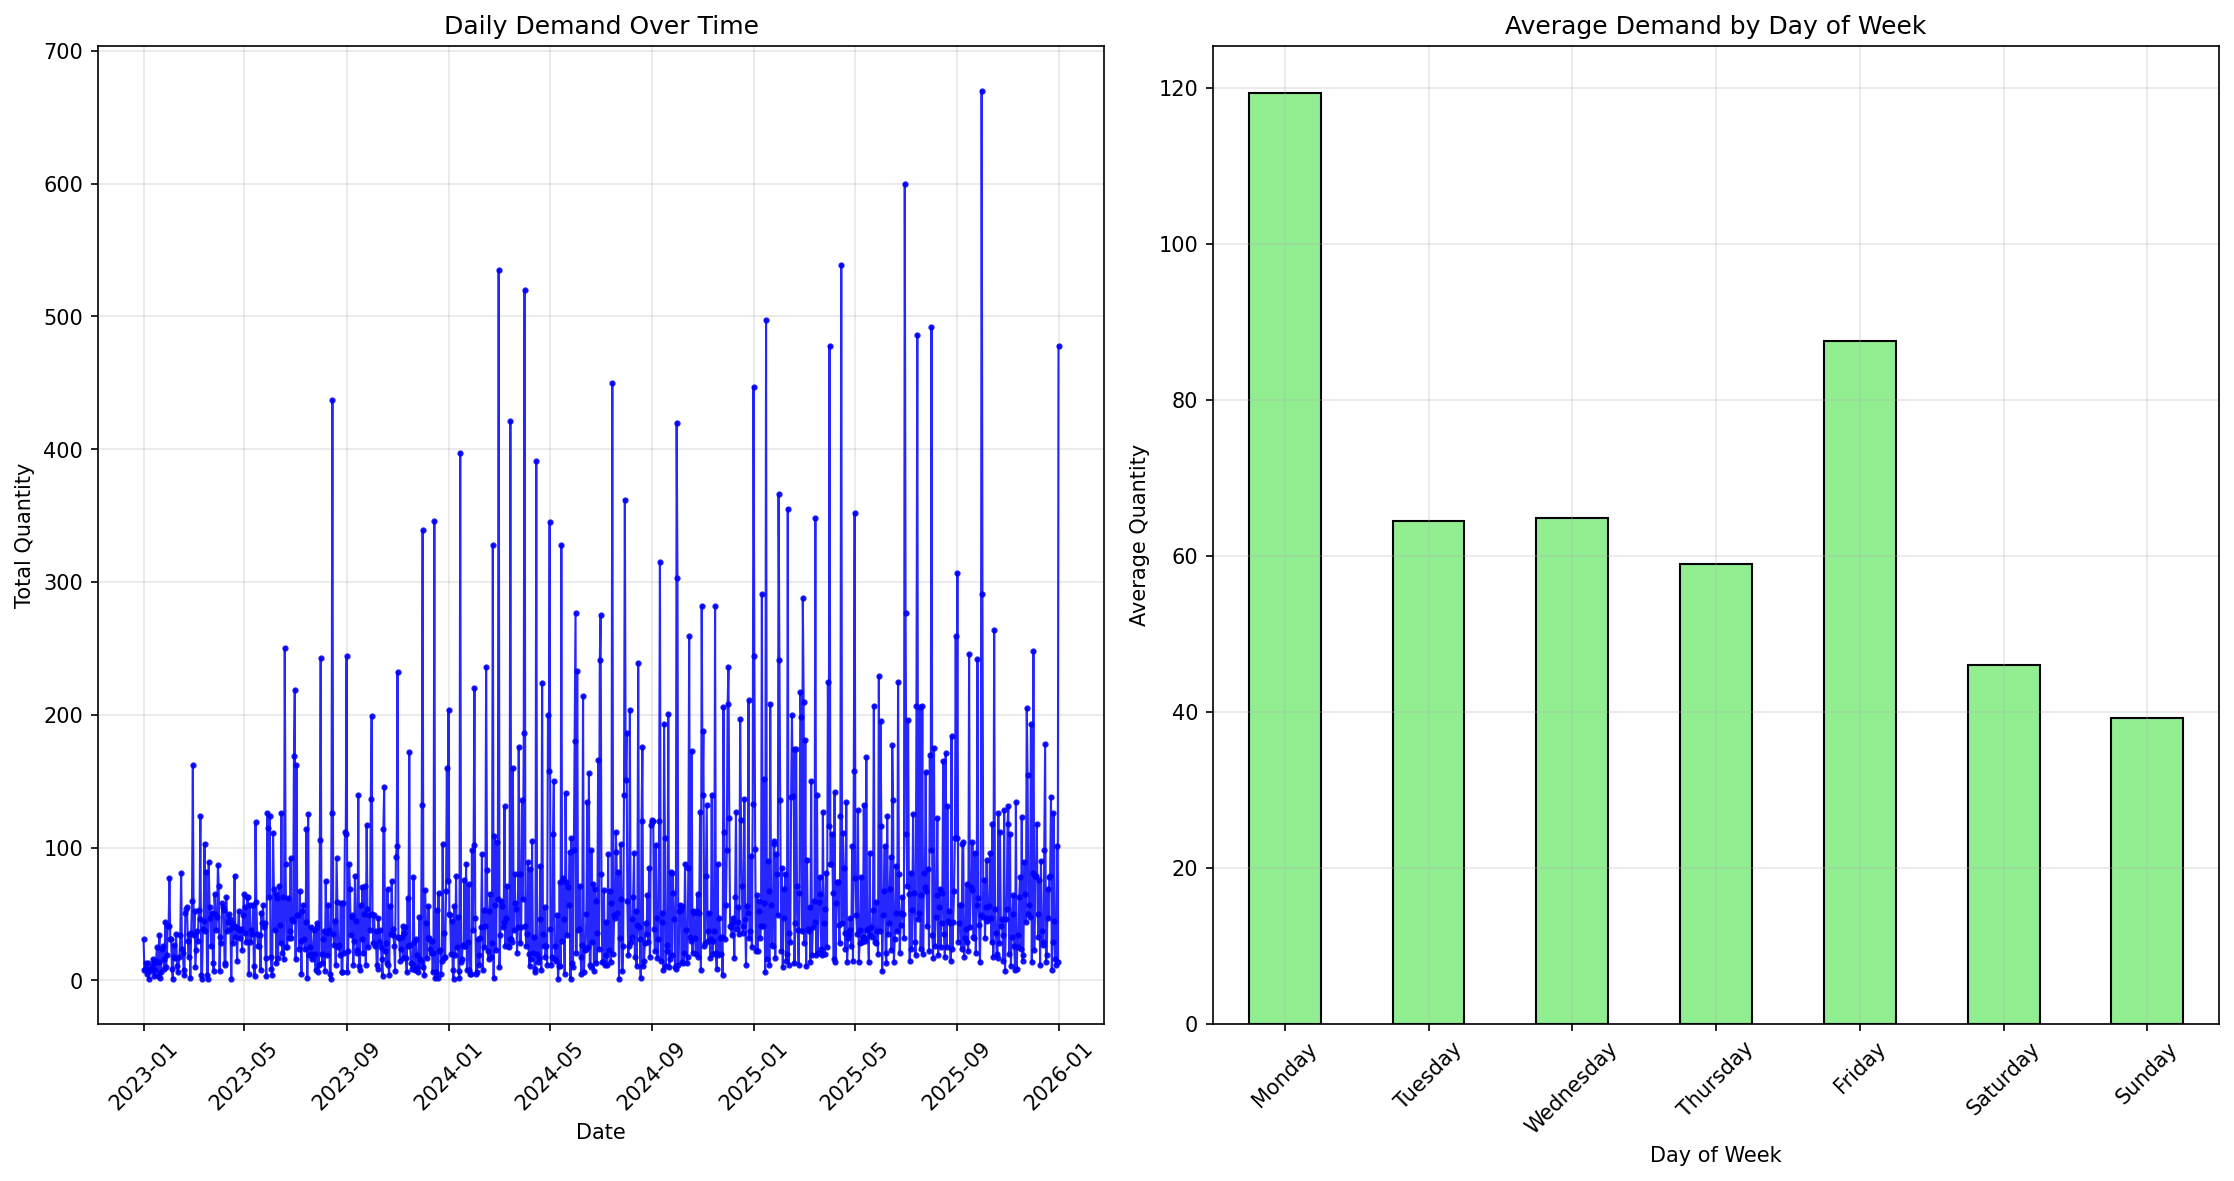

Saved plot: plots\time_series_analysis_daily.png

Running weekly analysis...

[WEEKLY] Statistics:
  Periods: 158
  Avg weekly demand: 475.30
  Weekly demand std: 238.02
  Periods with zero demand: 0
  Demand variability (CV): 0.501


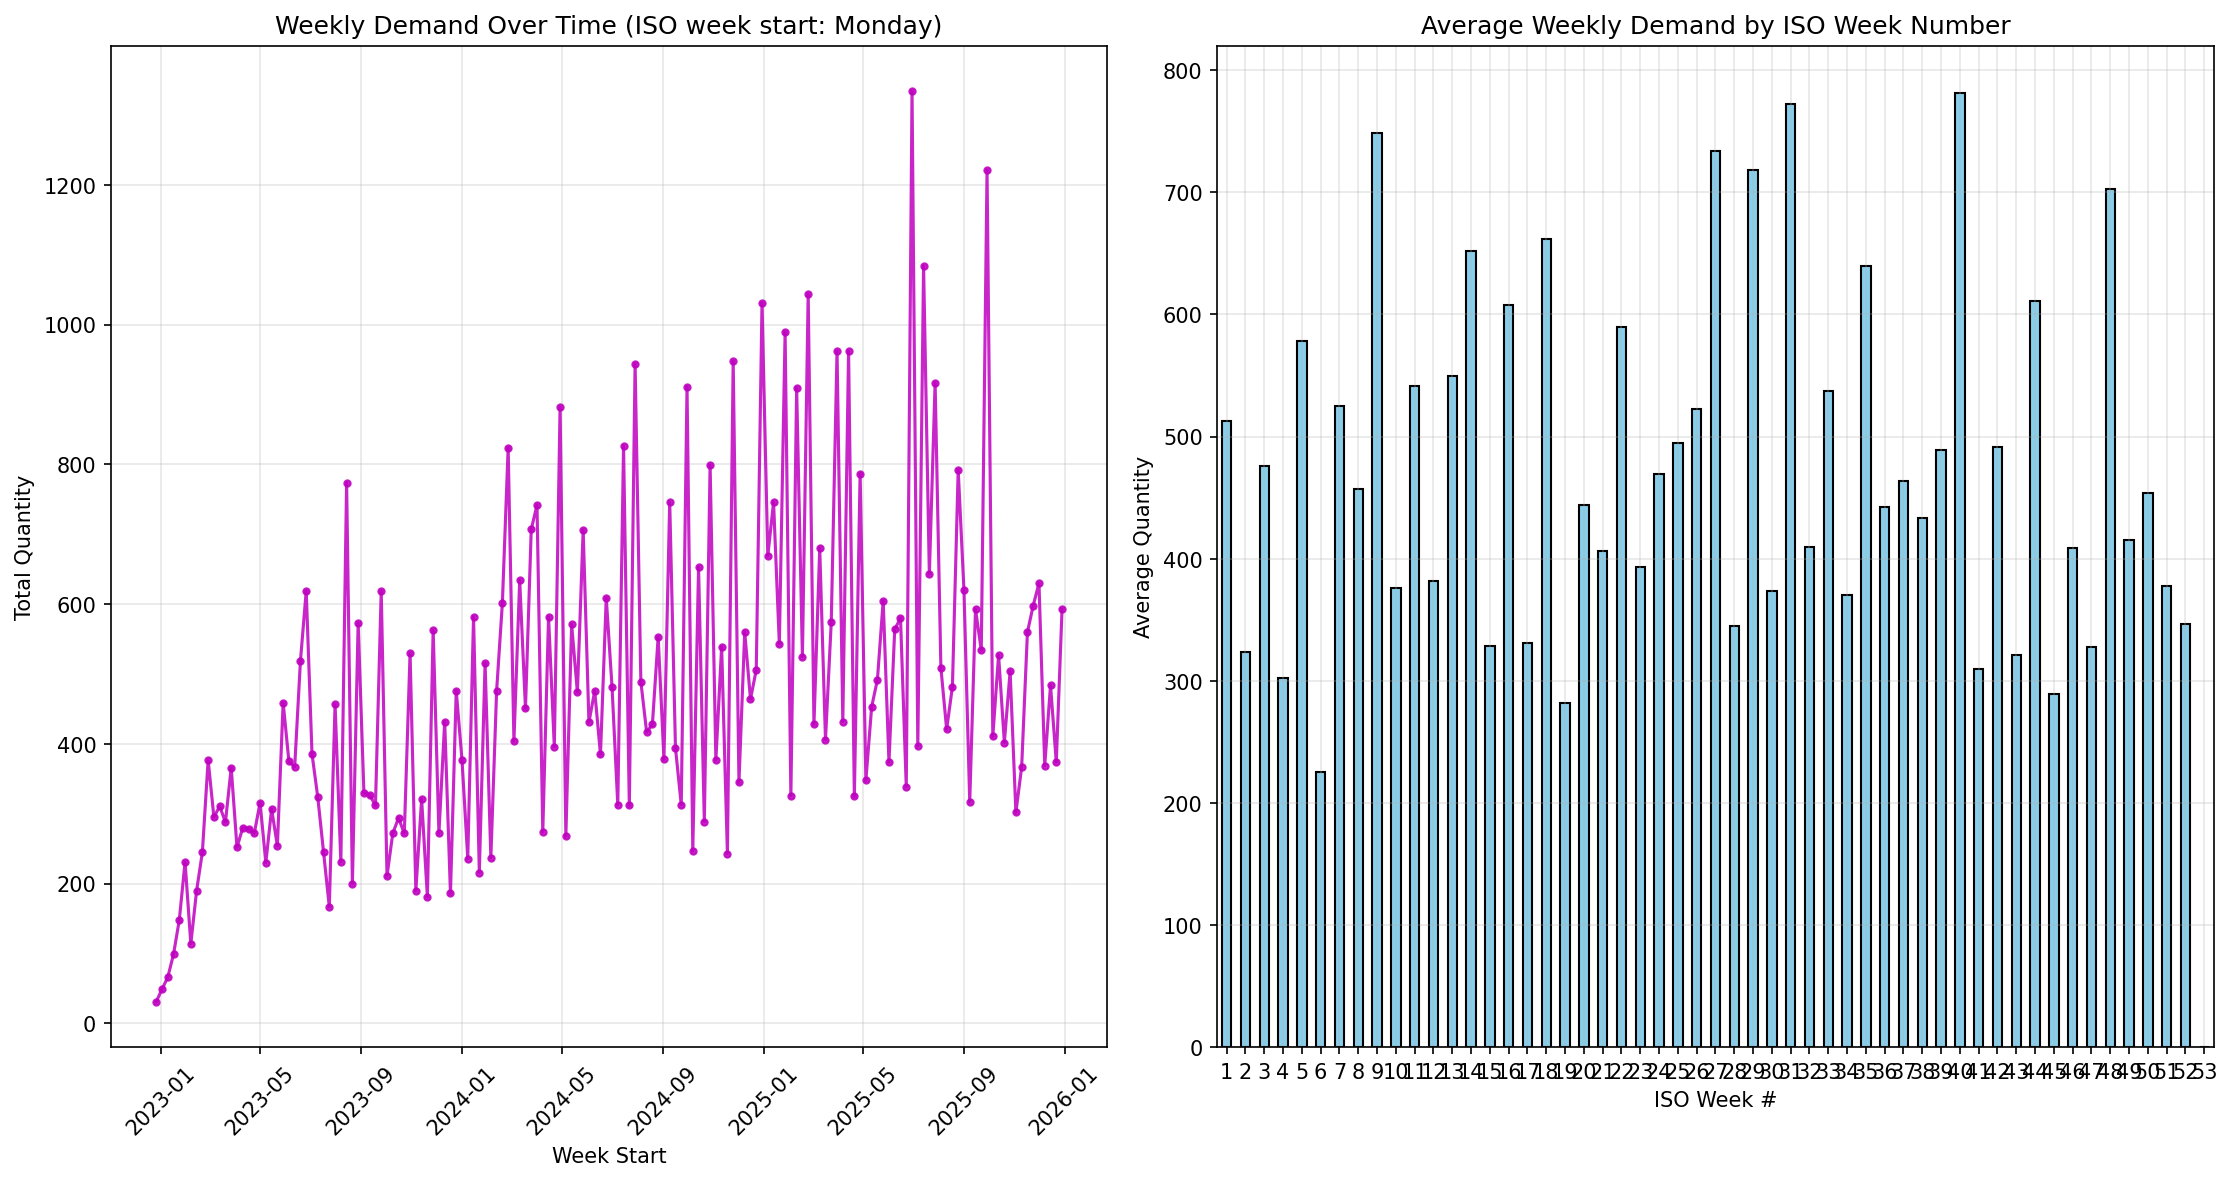

Saved plot: plots\time_series_analysis_weekly.png

Running monthly analysis...

[MONTHLY] Statistics:
  Periods: 36
  Avg monthly demand: 2086.03
  Monthly demand std: 647.11
  Periods with zero demand: 0
  Demand variability (CV): 0.310


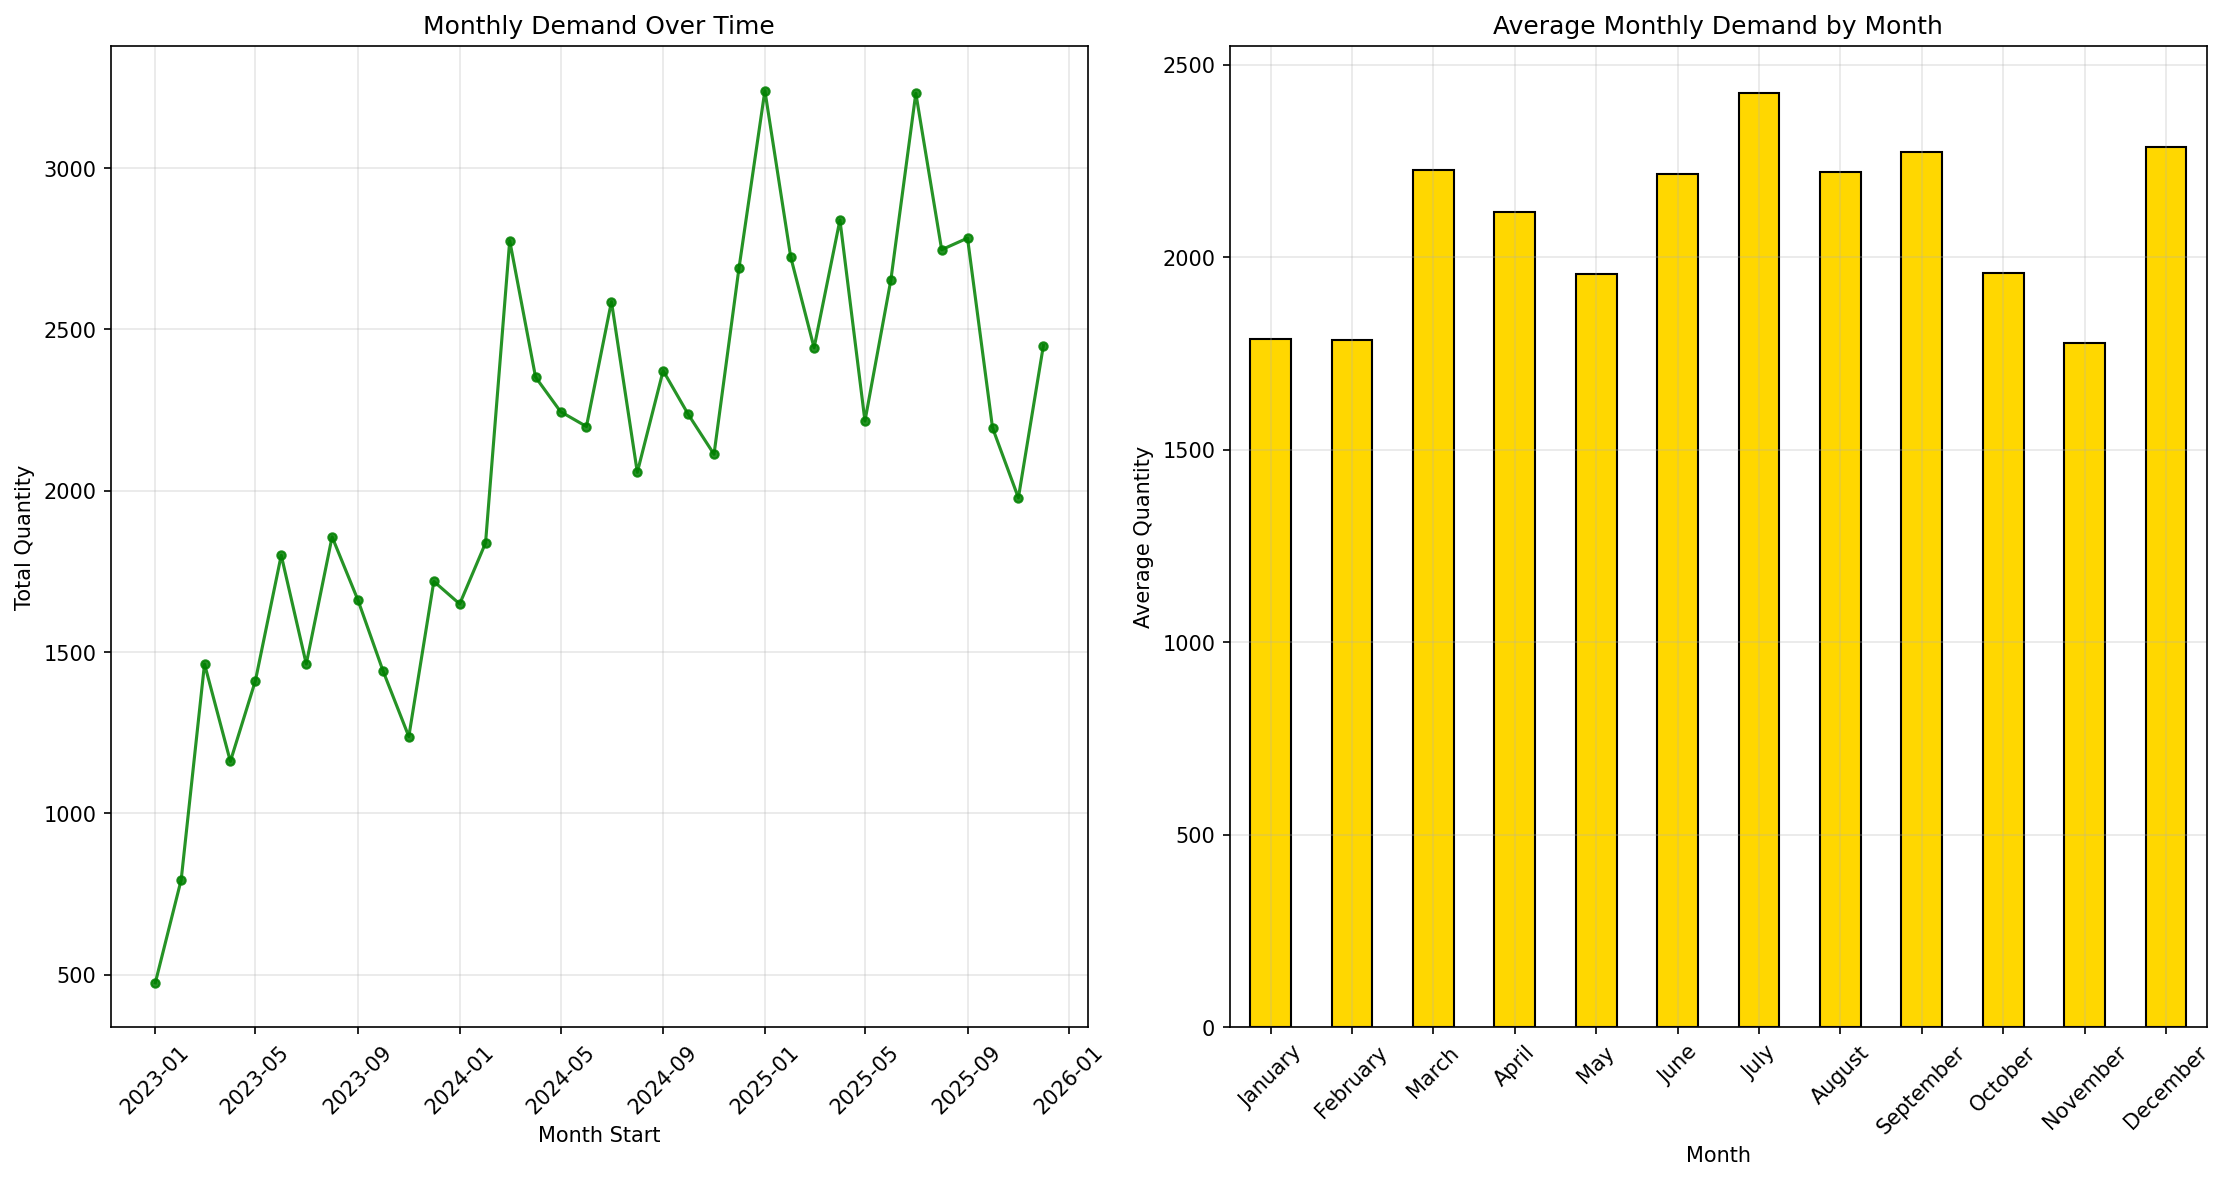

Saved plot: plots\time_series_analysis_monthly.png

Analysis complete.


In [57]:
def time_series_analysis(df, level=None):
    """Time series analysis at daily/weekly/monthly granularity and save/show plots."""
    print("\nTIME SERIES ANALYSIS")
    print("-" * 40)

    # normalize level; default to 'all'
    level = (level or "all").strip().lower()
    if level not in {"daily", "weekly", "monthly", "all"}:
        print(f"[WARN] Unknown level='{level}'. Falling back to 'all'.")
        level = "all"

    # required columns check (fast short-circuit)
    required_cols = ['Requirement Start Date', 'Quantity']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return df

    # cast date and quantity efficiently (strict=False avoids failing on bad rows)
    df = df.with_columns([
        pl.col('Requirement Start Date').cast(pl.Date).alias('Requirement Start Date'),
        pl.col('Quantity').cast(pl.Float64, strict=False).alias('Quantity')
    ])

    # filter valid date window [2023-01-01, 2026-01-01)
    start_date = dt.date(2023, 1, 1)
    end_date   = dt.date(2026, 1, 1)
    df_ts = df.filter(
        pl.col('Requirement Start Date').is_not_null() &
        (pl.col('Requirement Start Date') >= start_date) &
        (pl.col('Requirement Start Date') <  end_date)
    )

    if df_ts.is_empty():
        print("No valid dates found in the specified range (2023-01-01 to 2026-01-01).")
        return df

    # basic date range info
    mm = df_ts.select([
        pl.col('Requirement Start Date').min().alias('min_date'),
        pl.col('Requirement Start Date').max().alias('max_date')
    ]).to_pandas()
    print(f"Date Range: {mm['min_date'].iloc[0]} to {mm['max_date'].iloc[0]}")
    print(f"Records with valid dates: {len(df_ts):,}")

    # ensure output directory
    os.makedirs('plots', exist_ok=True)

    # helper: print simple stats from a pandas Series
    def _print_stats(name, series):
        vals = series.values
        avg = float(series.mean()) if len(vals) else float('nan')
        std = float(series.std()) if len(vals) else float('nan')
        zero_cnt = int((series == 0).sum())
        cv = (std / avg) if avg else float('nan')
        print(f"\n[{name.upper()}] Statistics:")
        print(f"  Periods: {len(vals)}")
        print(f"  Avg {name} demand: {avg:.2f}")
        print(f"  {name.capitalize()} demand std: {std:.2f}")
        print(f"  Periods with zero demand: {zero_cnt}")
        print(f"  Demand variability (CV): {cv:.3f}")

    # DAILY analysis and plot
    def _plot_daily():
        print("\nRunning daily analysis...")

        # aggregate daily in Polars (fast for large data)
        daily = (
            df_ts
            .group_by('Requirement Start Date')
            .agg(pl.col('Quantity').sum().alias('total_quantity'))
            .sort('Requirement Start Date')
        ).to_pandas()

        # pandas datetime for plotting
        daily['Requirement Start Date'] = pd.to_datetime(daily['Requirement Start Date'])
        daily.set_index('Requirement Start Date', inplace=True)

        # stats
        _print_stats("daily", daily['total_quantity'])

        # second subplot data: average by day of week
        temp = daily.reset_index()
        temp['day_of_week'] = temp['Requirement Start Date'].dt.day_name()
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        weekly_avg = temp.groupby('day_of_week')['total_quantity'].mean().reindex(day_order)

        # plot
        plt.figure(figsize=(15, 8))

        # daily line
        plt.subplot(1, 2, 1)
        plt.plot(daily.index, daily['total_quantity'].values, 'b-', linewidth=1, alpha=0.85, marker='o', markersize=2)
        plt.title('Daily Demand Over Time')
        plt.xlabel('Date')
        plt.ylabel('Total Quantity')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

        # avg by day of week
        plt.subplot(1, 2, 2)
        weekly_avg.plot(kind='bar', color='lightgreen', edgecolor='black')
        plt.title('Average Demand by Day of Week')
        plt.xlabel('Day of Week')
        plt.ylabel('Average Quantity')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        out_path = os.path.join('plots', 'time_series_analysis_daily.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close()
        display(Image(filename=out_path))
        print(f"Saved plot: {out_path}")

    # WEEKLY analysis and plot (ISO weeks starting Monday via truncate)
    def _plot_weekly():
        print("\nRunning weekly analysis...")

        # truncate dates to week start (Monday) and sum
        weekly = (
            df_ts
            .with_columns(pl.col('Requirement Start Date').dt.truncate("1w").alias('week_start'))
            .group_by('week_start')
            .agg(pl.col('Quantity').sum().alias('total_quantity'))
            .sort('week_start')
        ).to_pandas()

        # pandas datetime and index
        weekly['week_start'] = pd.to_datetime(weekly['week_start'])
        weekly.set_index('week_start', inplace=True)

        # stats
        _print_stats("weekly", weekly['total_quantity'])

        # second subplot data: average by ISO week number across years
        temp = weekly.reset_index()
        temp['iso_week'] = temp['week_start'].dt.isocalendar().week
        week_order = list(range(1, 54))
        by_weeknum = temp.groupby('iso_week')['total_quantity'].mean().reindex(week_order)

        # plot
        plt.figure(figsize=(15, 8))

        # weekly line
        plt.subplot(1, 2, 1)
        plt.plot(weekly.index, weekly['total_quantity'].values, 'm-', linewidth=1.5, alpha=0.85, marker='o', markersize=3)
        plt.title('Weekly Demand Over Time (ISO week start: Monday)')
        plt.xlabel('Week Start')
        plt.ylabel('Total Quantity')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

        # avg by ISO week number
        plt.subplot(1, 2, 2)
        by_weeknum.plot(kind='bar', color='#87CEEB', edgecolor='black')
        plt.title('Average Weekly Demand by ISO Week Number')
        plt.xlabel('ISO Week #')
        plt.ylabel('Average Quantity')
        plt.xticks(rotation=0)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        out_path = os.path.join('plots', 'time_series_analysis_weekly.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close()
        display(Image(filename=out_path))
        print(f"Saved plot: {out_path}")

    # MONTHLY analysis and plot
    def _plot_monthly():
        print("\nRunning monthly analysis...")

        # truncate to month start and sum
        monthly = (
            df_ts
            .with_columns(pl.col('Requirement Start Date').dt.truncate("1mo").alias('month_start'))
            .group_by('month_start')
            .agg(pl.col('Quantity').sum().alias('total_quantity'))
            .sort('month_start')
        ).to_pandas()

        # pandas datetime and index
        monthly['month_start'] = pd.to_datetime(monthly['month_start'])
        monthly.set_index('month_start', inplace=True)

        # stats
        _print_stats("monthly", monthly['total_quantity'])

        # second subplot data: average by month across years
        temp = monthly.reset_index()
        temp['month'] = temp['month_start'].dt.month
        month_order = list(range(1, 13))
        by_month = temp.groupby('month')['total_quantity'].mean().reindex(month_order)
        month_labels = [calendar.month_name[m] for m in by_month.index]

        # plot
        plt.figure(figsize=(15, 8))

        # monthly line
        plt.subplot(1, 2, 1)
        plt.plot(monthly.index, monthly['total_quantity'].values, 'g-', linewidth=1.5, alpha=0.85, marker='o', markersize=4)
        plt.title('Monthly Demand Over Time')
        plt.xlabel('Month Start')
        plt.ylabel('Total Quantity')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

        # avg by month name
        plt.subplot(1, 2, 2)
        pd.Series(by_month.values, index=month_labels).plot(kind='bar', color='#FFD700', edgecolor='black')
        plt.title('Average Monthly Demand by Month')
        plt.xlabel('Month')
        plt.ylabel('Average Quantity')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        out_path = os.path.join('plots', 'time_series_analysis_monthly.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close()
        display(Image(filename=out_path))
        print(f"Saved plot: {out_path}")

    # dispatch based on level; default runs all
    if level == "daily":
        _plot_daily()
    elif level == "weekly":
        _plot_weekly()
    elif level == "monthly":
        _plot_monthly()
    else:
        _plot_daily()
        _plot_weekly()
        _plot_monthly()

    print("\nAnalysis complete.")
    return df


# Usage:
df = time_series_analysis(df)                # runs all (daily + weekly + monthly)
# df = time_series_analysis(df, level="daily") # run only daily
# df = time_series_analysis(df, level="weekly")# run only weekly


### Demand Insights Section - SubPractice Trends

In [58]:
def monthly_demand_analysis(df, practice_area, sub_keywords, practice, label, display_plots=True, excel_path=None):
    "Plot monthly demand, highlight stable vs volatile; supports overall and 'all'; saves images + Excel."

    # check required columns
    req = ['Requirement Start Date', 'Quantity', 'Practice Area', 'SubPractice']
    miss = [c for c in req if c not in df.columns]
    if miss:
        print(f"Missing columns: {miss}")
        return df

    # cast essential columns
    df = df.with_columns([
        pl.col('Requirement Start Date').cast(pl.Date),
        pl.col('Quantity').cast(pl.Float64, strict=False),
        pl.col('Practice Area').cast(pl.Utf8),
        pl.col('Practice').cast(pl.Utf8),
        pl.col('SubPractice').cast(pl.Utf8).fill_null("")
    ])

    # early filter window and practice area
    start_date = dt.date(2025, 1, 1)
    end_date   = dt.date(2026, 1, 1)
    df_base = df.filter(
        (pl.col('Practice') == practice) &
        (pl.col('Practice Area') == practice_area) &
        (pl.col('Requirement Start Date') >= start_date) &
        (pl.col('Requirement Start Date') < end_date)
    )
    if df_base.is_empty():
        print("No data found for given practice area and date range.")
        return df

    # build target views: overall, all subpractices, and keywords
    targets = []
    want_all = False
    if not sub_keywords:
        targets.append({'type': 'overall', 'label': label})
    else:
        for k in sub_keywords:
            if k is None or (isinstance(k, str) and k.strip() == ""):
                targets.append({'type': 'overall', 'label': label})
            elif isinstance(k, str) and k.strip().lower() == 'all':
                want_all = True
            else:
                targets.append({'type': 'keyword', 'label': str(k).strip()})
        if want_all:
            subs = df_base.select(pl.col('SubPractice').unique()).to_series().to_list()
            for sp in subs:
                if isinstance(sp, str) and sp.strip() != "":
                    targets.append({'type': 'subexact', 'label': sp.strip()})
                    
    
    # output dir
    out_dir = os.path.join('plots' , 'demand_analysis')
    os.makedirs(out_dir, exist_ok=True)

    # collect for Excel
    summary_rows = []
    monthly_frames = {}

    for tgt in targets:
        # choose filter
        if tgt['type'] == 'overall':
            df_filtered = df_base
            view_label = label
            file_tag = label
        elif tgt['type'] == 'subexact':
            df_filtered = df_base.filter(pl.col('SubPractice') == tgt['label'])  # exact
            if df_filtered.is_empty():
                continue
            view_label = tgt['label']
            file_tag = view_label.replace(' ', '_')
        else:
            df_filtered = df_base.filter(  # contains
                pl.col('SubPractice').str.to_lowercase().str.contains(tgt['label'].lower())
            )
            if df_filtered.is_empty():
                continue
            view_label = tgt['label']
            file_tag = view_label.replace(' ', '_')

        # monthly aggregate
        monthly = (
            df_filtered
            .with_columns(pl.col('Requirement Start Date').dt.truncate("1mo").alias('month_start'))
            .group_by('month_start')
            .agg(pl.col('Quantity').sum().alias('total_quantity'))
            .sort('month_start')
        )

        # to pandas for plotting
        mpd = monthly.to_pandas()
        if mpd.empty:
            continue
        mpd['month_start'] = pd.to_datetime(mpd['month_start'])
        mpd = mpd.set_index('month_start').sort_index()

        # stats
        vals = mpd['total_quantity'].astype(float).values
        avg_demand = float(np.nanmean(vals))
        median_demand = float(np.nanmedian(vals))
        std_demand = float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else 0.0
        total_demand = float(np.nansum(vals))
        min_demand = float(np.nanmin(vals)) if len(vals) else 0.0
        max_demand = float(np.nanmax(vals)) if len(vals) else 0.0
        months_count = int(len(vals))

        # cutoff band for stability
        upper = avg_demand + std_demand
        lower = avg_demand - std_demand
        
        stable_mask = (vals >= lower) & (vals <= upper)
        volatile_mask = ~stable_mask
        stable_n = int(stable_mask.sum())
        volatile_n = int(volatile_mask.sum())

        # figure with 2 plots
        fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

        # plot 1: demand + mean/median/+/-1 std (data std)
        axes[0].plot(mpd.index, vals, color='teal', marker='o', linewidth=1.5)
        axes[0].axhline(avg_demand, color='navy', linestyle='--', linewidth=1, alpha=0.85, label='Mean')
        axes[0].axhline(median_demand, color='orange', linestyle='-.', linewidth=1, alpha=0.9, label='Median')
        axes[0].axhline(avg_demand + std_demand, color='purple', linestyle=':', linewidth=1, alpha=0.9, label='+1 Std')
        axes[0].axhline(avg_demand - std_demand, color='purple', linestyle=':', linewidth=1, alpha=0.9, label='-1 Std')
        axes[0].set_title(f"Monthly Demand for {practice_area} - {view_label}")
        axes[0].set_ylabel("Total Quantity")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(frameon=False, ncol=4)
        axes[0].text(0.01, 0.95,
                     f"Mean: {avg_demand:.2f}\nMedian: {median_demand:.2f}\nStd: {std_demand:.2f}",
                     transform=axes[0].transAxes, va='top', ha='left', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='gray'))

        # plot 2: stable vs volatile + cutoff band
        axes[1].plot(mpd.index, vals, color='gray', linewidth=1.0, alpha=0.6)
        axes[1].scatter(mpd.index[stable_mask], vals[stable_mask], color='tab:green', label=f"Stable (±{std_demand})", zorder=3)
        axes[1].scatter(mpd.index[volatile_mask], vals[volatile_mask], color='tab:red', label="Volatile", zorder=3)
        axes[1].axhline(avg_demand, color='navy', linestyle='--', linewidth=1, alpha=0.85, label='Mean')
        axes[1].axhline(median_demand, color='orange', linestyle='-.', linewidth=1, alpha=0.9, label='Median')
        axes[1].axhline(upper, color='tab:green', linestyle=':', linewidth=1, alpha=0.9, label='+ Cutoff')
        axes[1].axhline(lower, color='tab:green', linestyle=':', linewidth=1, alpha=0.9, label='- Cutoff')
        axes[1].fill_between(mpd.index, lower, upper, color='tab:green', alpha=0.08)
        axes[1].set_ylabel("Total Quantity")
        axes[1].set_xlabel("Month")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(frameon=False, ncol=5)
        axes[1].text(0.01, 0.95,
                     f"Mean: {avg_demand:.2f} | Median: {median_demand:.2f} | Std: {std_demand:.2f}\n"
                     f"Stable months: {stable_n} | Volatile months: {volatile_n}",
                     transform=axes[1].transAxes, va='top', ha='left', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.6, edgecolor='gray'))

        # layout and save
        plt.xticks(rotation=45)
        plt.tight_layout()
        safe_tag = re.sub(r'[\\/*?:"<>|]', '_', file_tag)  # remove invalid chars
        fname = f"monthly_demand_{practice_area}_{safe_tag}.png".replace(" ", "_")
        path = os.path.join(out_dir, fname)
        plt.savefig(path, dpi=150, bbox_inches='tight')
        plt.close(fig)

        # display inline based on flag
        if display_plots:
            display(Image(filename=path))

        # summary row for Excel
        summary_rows.append({
            'Practice Area': practice_area,
            'View': view_label,
            'Months': months_count,
            'Total Demand': total_demand,
            'Mean': avg_demand,
            'Median': median_demand,
            'Std': std_demand,
            'Min': min_demand,
            'Max': max_demand,
            'Stable Months (±cutoff)': stable_n,
            'Volatile Months (±cutoff)': volatile_n,
            'Std Cutoff Used': float(std_demand),
            'Image Path': path
        })

        # monthly sheet frame
        monthly_frames[f"monthly_{file_tag}"] = (
            mpd.reset_index().rename(columns={'month_start': 'Month', 'total_quantity': 'Total Quantity'})
        )

    # Excel path default
    if excel_path is None:
        excel_path = os.path.join(out_dir, f"summary_{practice_area}.xlsx".replace(" ", "_"))

    # write Excel summary and monthly sheets
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        pd.DataFrame(summary_rows).to_excel(writer, sheet_name='summary', index=False)
        for sheet_name, frame in monthly_frames.items():
            safe_sheet = re.sub(r'[\\/*?:"<>|]', '_', sheet_name)[:31]  # sanitize invalid chars  # Excel sheet name limit
            frame.to_excel(writer, sheet_name=safe_sheet, index=False)

    if display_plots:
        print(f"Saved Excel: {excel_path}")

    return df


#### Filter Service line = EPS and SPE; within these all sub practice area level total demand for last 1 year

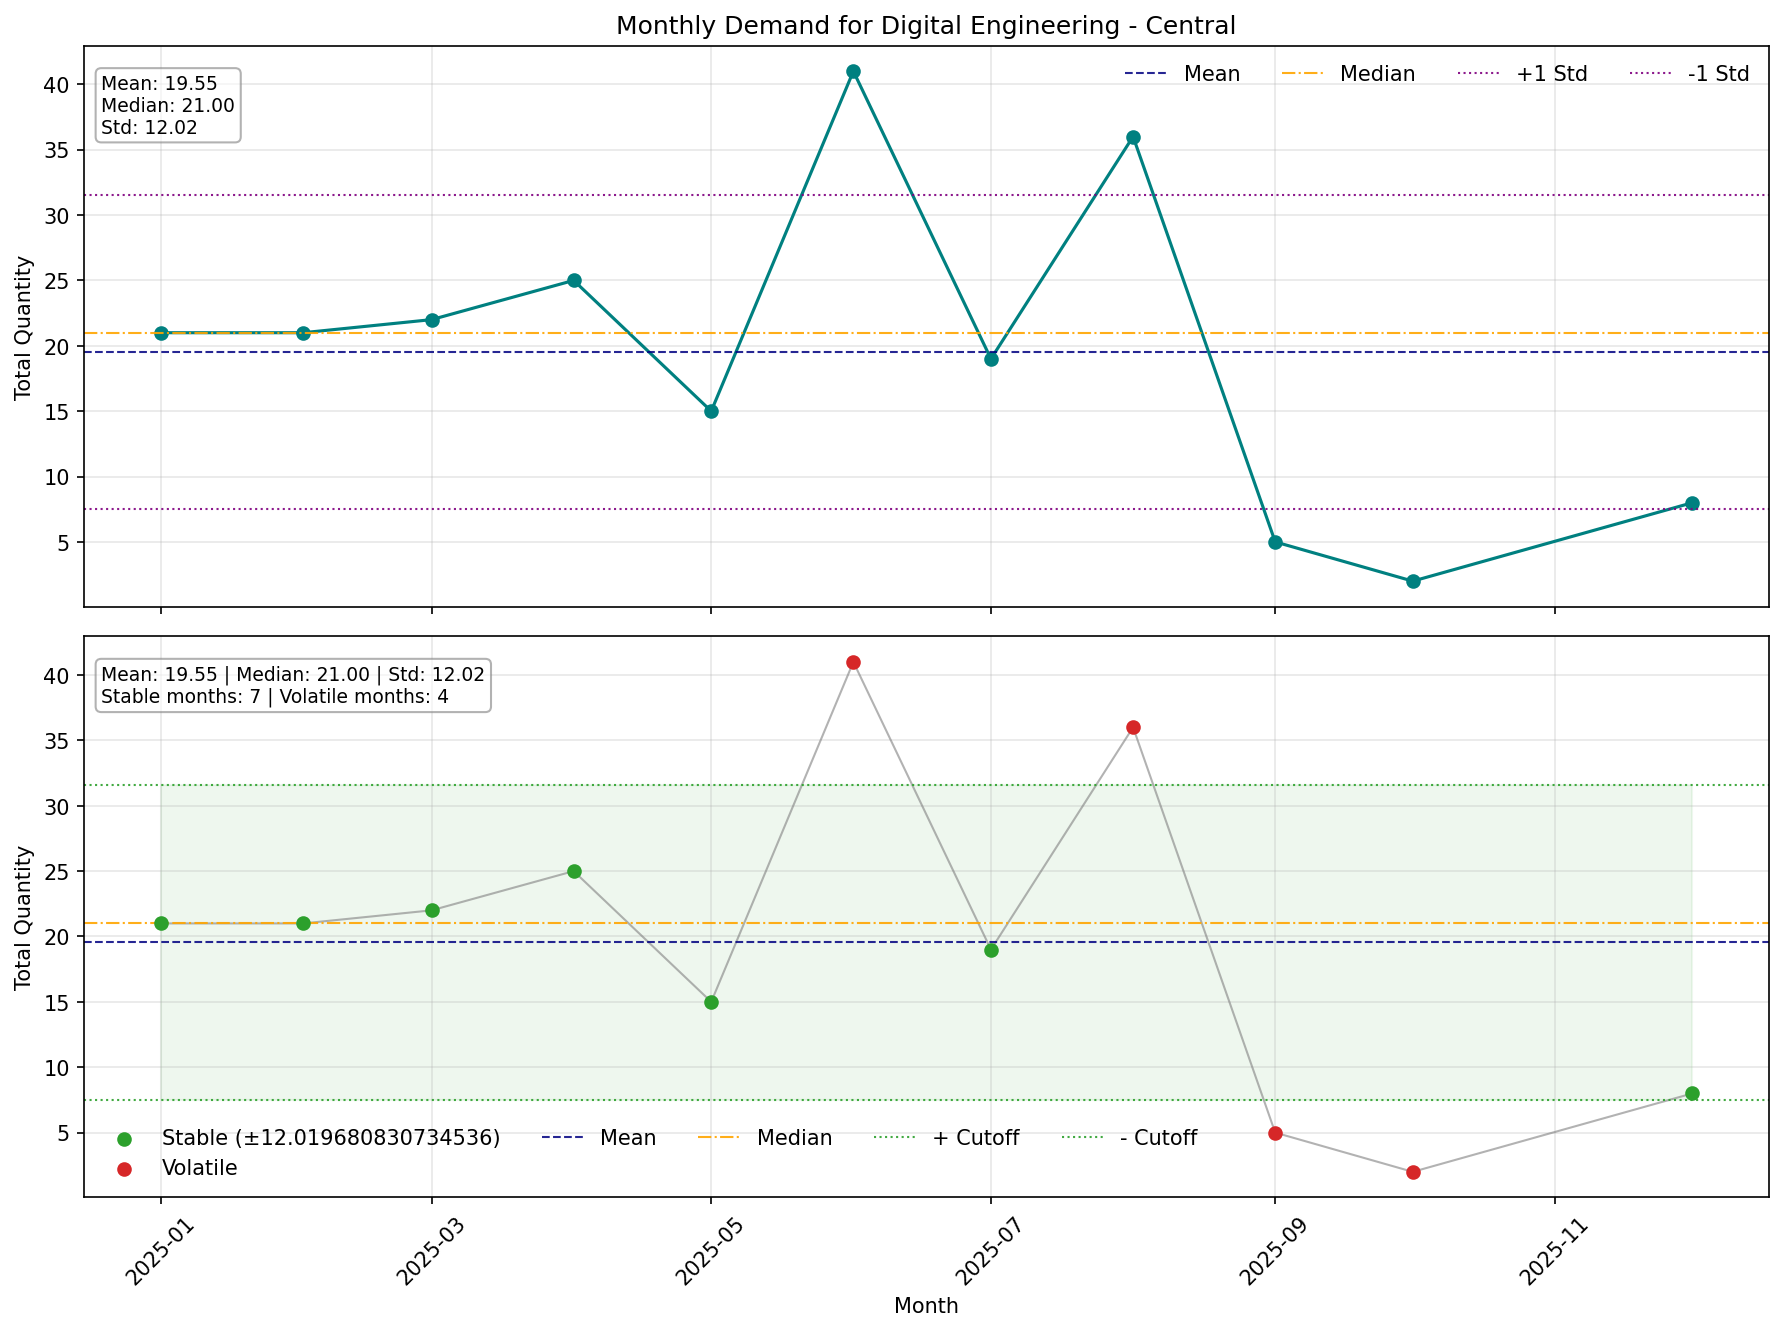

Saved Excel: plots\demand_analysis\summary_Digital_Engineering.xlsx


In [59]:
df = monthly_demand_analysis(df, practice_area="Digital Engineering", practice="DE Central", label="Central", sub_keywords=[], display_plots=True)

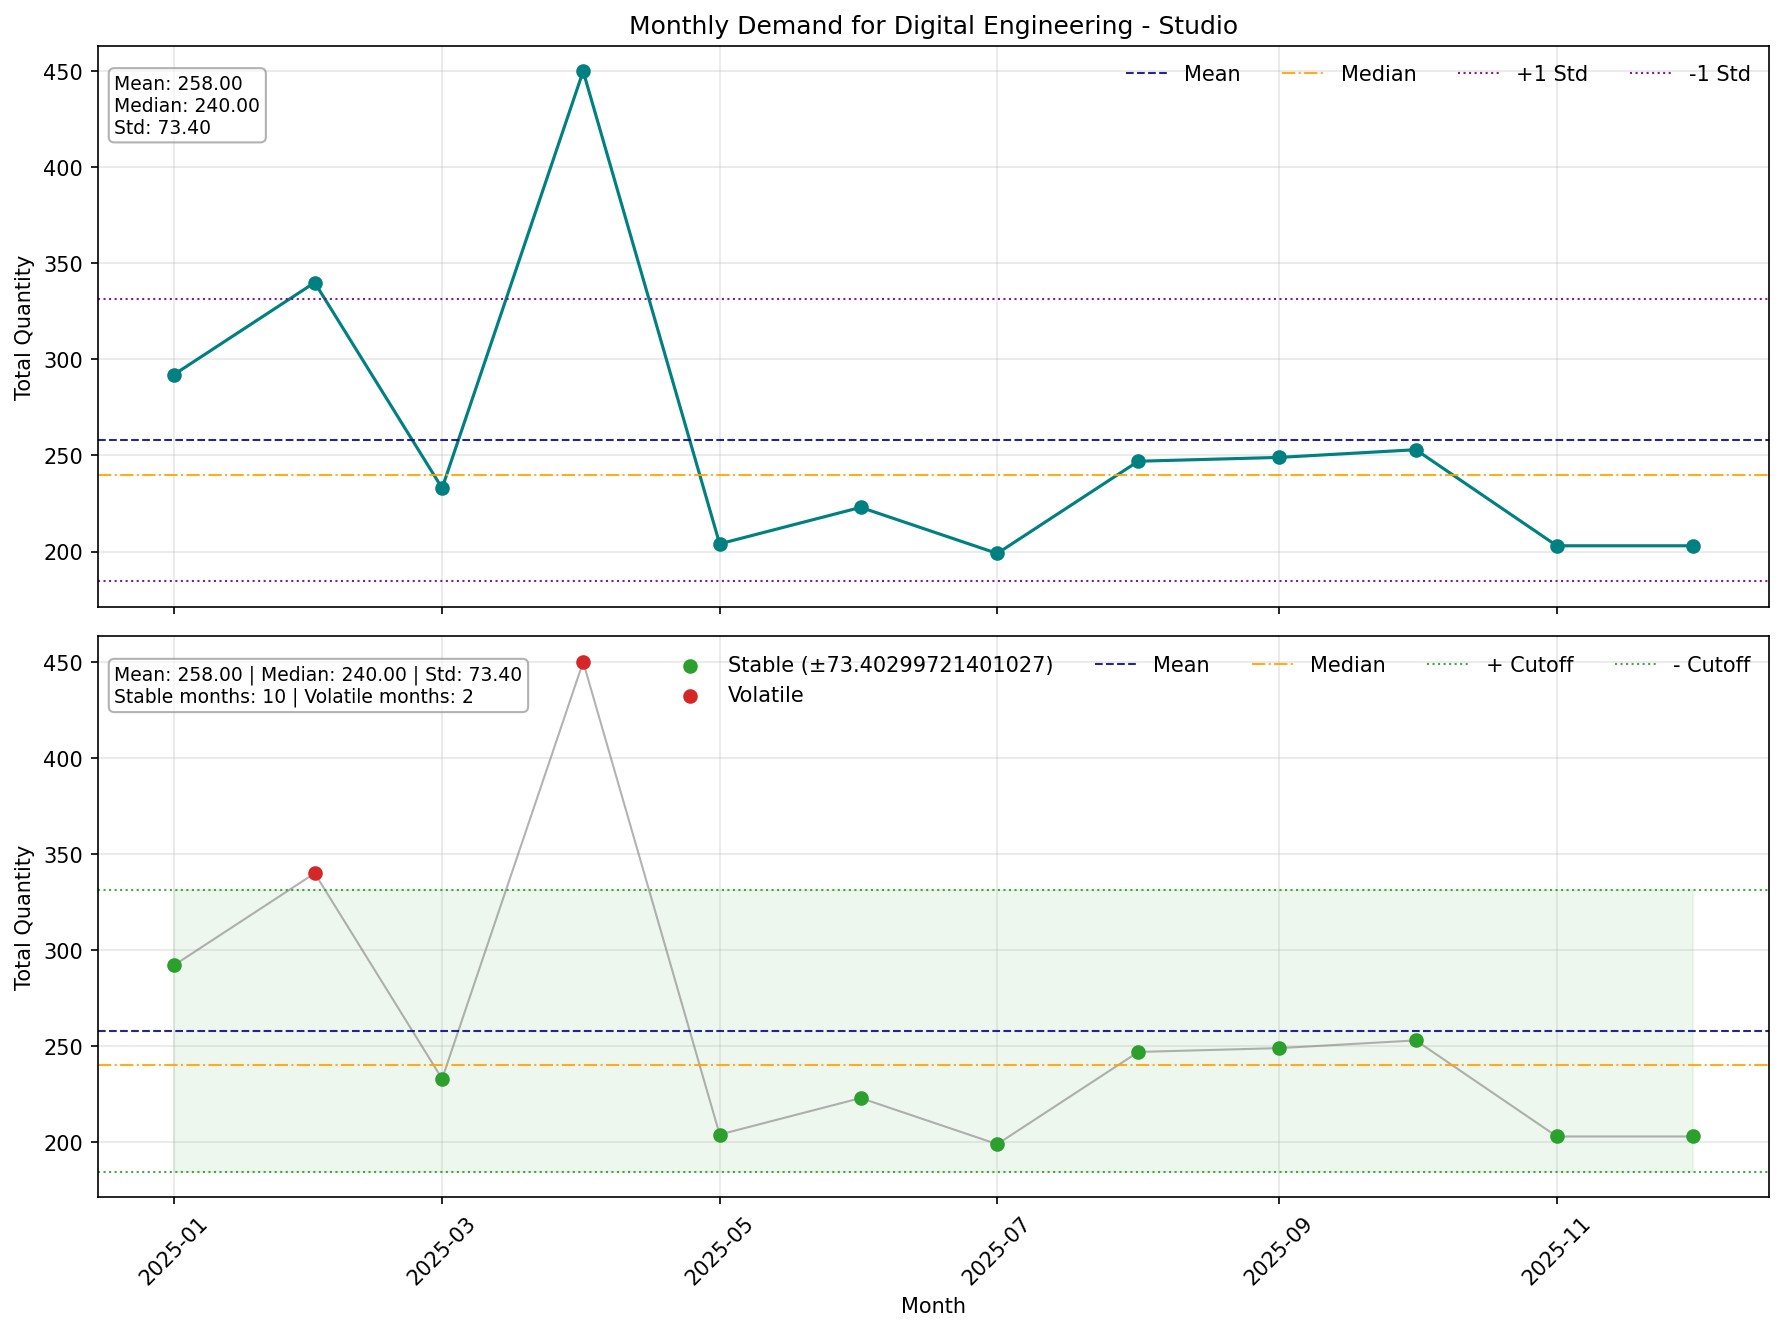

Saved Excel: plots\demand_analysis\summary_Digital_Engineering.xlsx


In [60]:
df = monthly_demand_analysis(df, practice_area="Digital Engineering", practice="DE Studio", label="Studio", sub_keywords=[], display_plots=True)

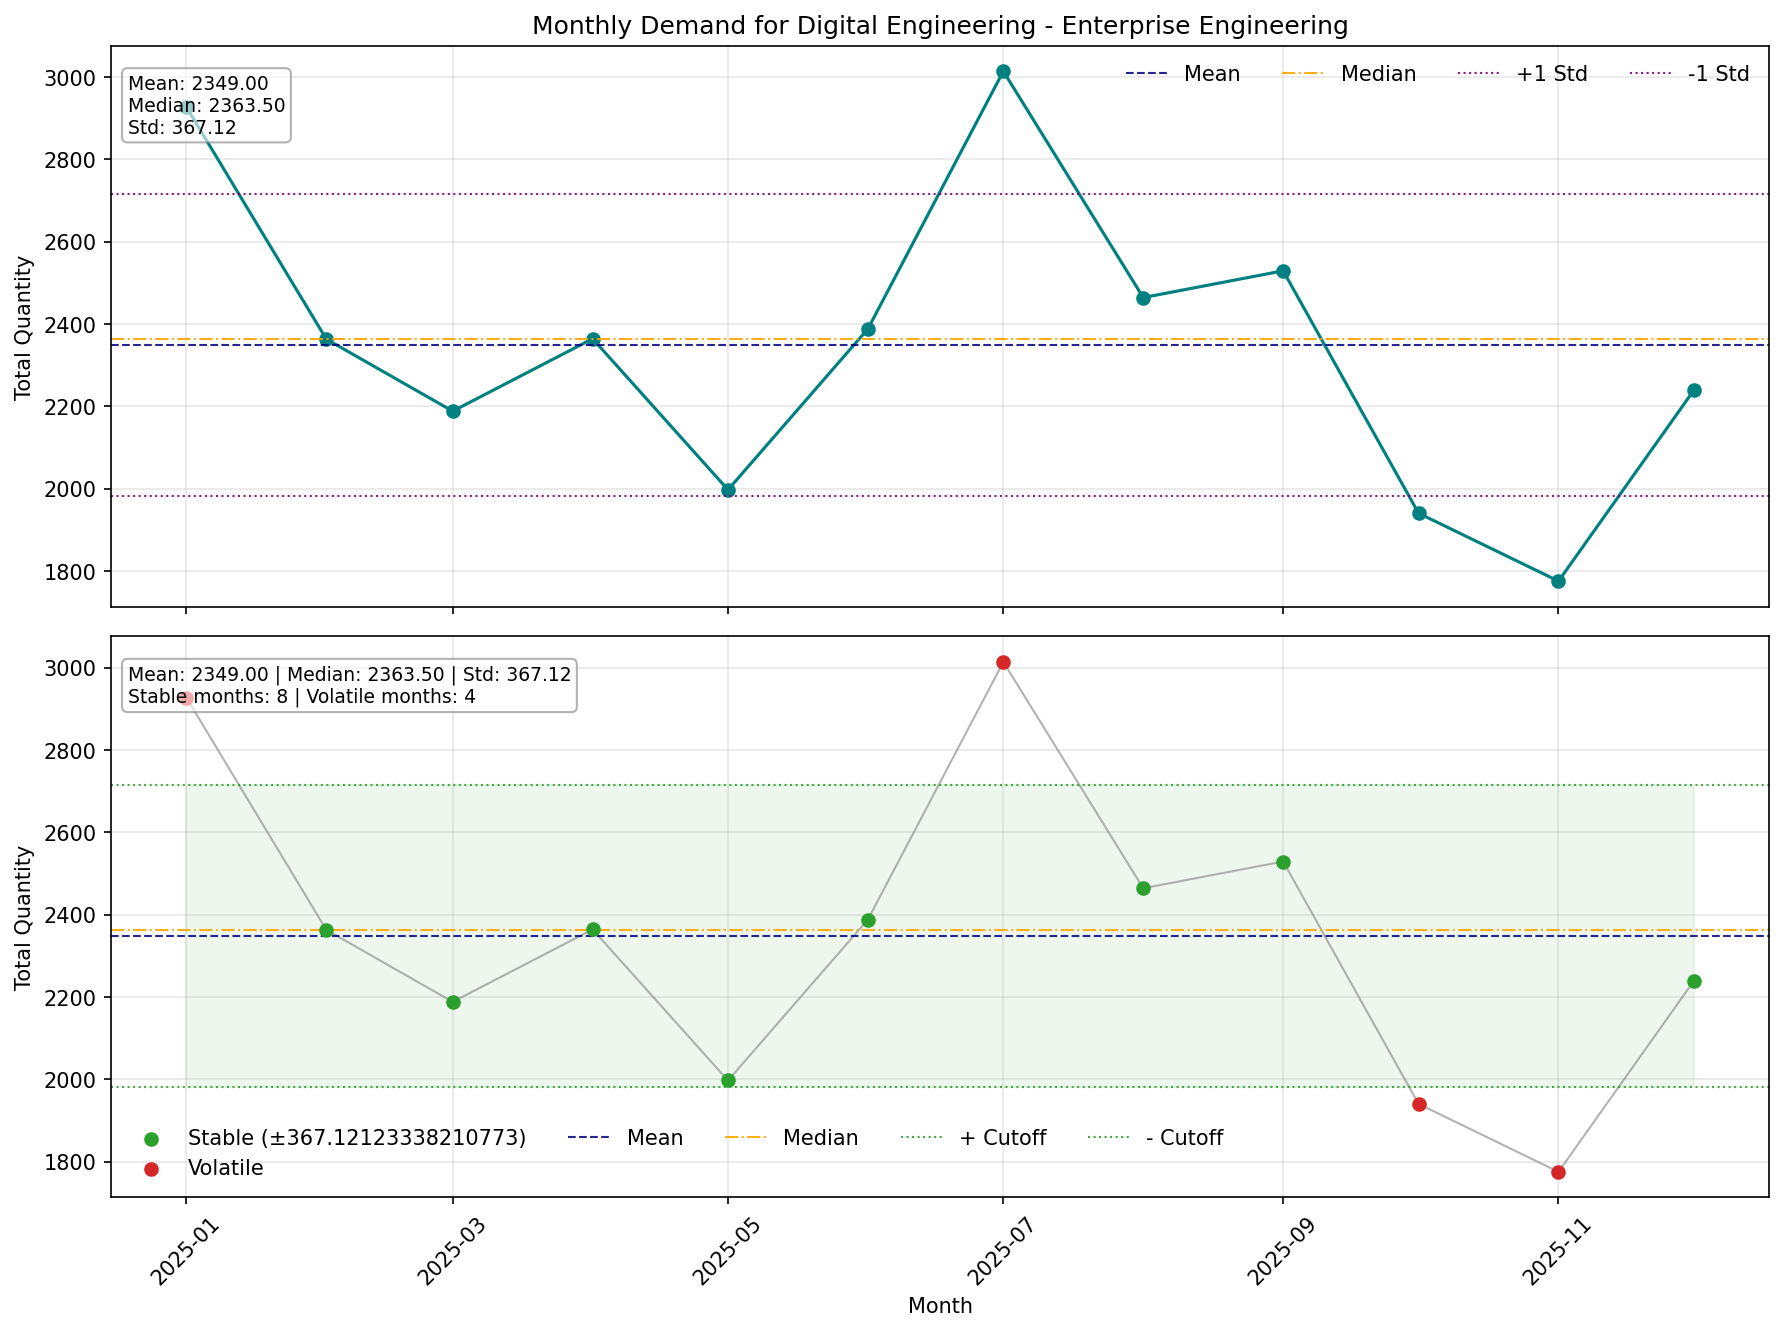

Saved Excel: plots\demand_analysis\summary_Digital_Engineering.xlsx


In [61]:
df = monthly_demand_analysis(df, practice_area="Digital Engineering", practice="DE Enterprise Engineering", label="Enterprise Engineering", sub_keywords=[], display_plots=True)

In [62]:
# df = monthly_demand_analysis(df, practice_area="EPS", practice="EPS SAP", label="SAP", sub_keywords=[], display_plots=True)

In [63]:
# df = monthly_demand_analysis(df, practice_area="EPS", sub_keywords=["Oracle", "SAP", "CX"])

In [64]:
# df = monthly_demand_analysis(df, practice_area="ADM", practice="ADM", sub_keywords=[])

#### Trends – For all sub practice areas – excel with mean, median, STD for time series.


In [65]:
# df = monthly_demand_analysis(df, practice_area="ADM", sub_keywords=["all"], display_plots=False)

In [66]:
# df = monthly_demand_analysis(df, practice_area="EPS", sub_keywords=["all"], display_plots=False)

#### Service Line: Total demand for last 1 year across Service line -  data without Service line and practice area filter

In [67]:
def service_line_analysis(df):
    """Analyze total demand by ServiceLine for last 1 year and save/show plot."""
    print("\nSERVICE LINE ANALYSIS")
    print("-" * 40)

    required_cols = ['Requirement Start Date', 'Quantity', 'ServiceLine']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return df

    # Cast columns + decode HTML entities safely using map_elements
    df = df.with_columns([
        pl.col('Requirement Start Date').cast(pl.Date).alias('Requirement Start Date'),
        pl.col('Quantity').cast(pl.Float64, strict=False).alias('Quantity'),
        pl.col('ServiceLine')
          .cast(pl.Utf8)
          .map_elements(lambda s: unescape(s) if s is not None else s)
          .alias('ServiceLine')
    ])

    # Filter last 1 year
    max_date = df.select(pl.col('Requirement Start Date').max()).item()
    if max_date is None:
        print("No valid dates found.")
        return df

    one_year_ago = max_date - dt.timedelta(days=365)
    df_last_year = df.filter(pl.col('Requirement Start Date') >= one_year_ago)

    if df_last_year.is_empty():
        print("No data in the last 1 year.")
        return df

    # Metrics: row count vs sum of Quantity
    records_last_year = df_last_year.height
    total_quantity_last_year = df_last_year.select(
        pl.col('Quantity').fill_null(0).sum()
    ).item()

    print(f"Records in last 1 year (row count): {records_last_year:,}")
    print(f"Total demand in last 1 year (sum of Quantity): {int(total_quantity_last_year):,}")

    # Aggregate by ServiceLine (sum Quantity)
    service_stats = (
        df_last_year
        .group_by('ServiceLine')
        .agg(pl.col('Quantity').fill_null(0).sum().alias('total_demand'))
        .sort('total_demand', descending=True)
        .to_pandas()
    )

    # Print stats
    total_sum = service_stats['total_demand'].sum()
    print("\nServiceLine Demand (sum of Quantity):")
    for _, row in service_stats.iterrows():
        name = row['ServiceLine'] or ''
        demand = row['total_demand']
        pct = (demand / total_sum) * 100 if total_sum else 0
        print(f"  {name:<40} {int(demand):>10,} ({pct:5.1f}%)")

    if int(total_sum) == int(records_last_year):
        print("\nNote: Sum of Quantity equals the number of records in the last year. "
              "This suggests Quantity is 1 per record (or effectively counts records).")

    # Ensure plots folder
    os.makedirs('plots', exist_ok=True)
    out_path = os.path.join('plots', 'service_line_analysis.png')

    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(service_stats['ServiceLine'], service_stats['total_demand'], color='steelblue')
    plt.title('Total Demand by ServiceLine (Last 1 Year)')
    plt.ylabel('Total Quantity')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height):,}", ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()

    # Use IPython.display explicitly
    try:
        display(Image.open(out_path))
    except Exception as e:
        print(f"(Display skipped) {e}")

    print(f"Saved plot: {out_path}")

    return df


# df = service_line_analysis(df)

#### Location – Onshore offshore split – column ref [“Off/On”] and then Country wise total demand split


LOCATION & COUNTRY DEMAND ANALYSIS
----------------------------------------

Onshore vs Offshore Split:
  offshore             3,612 ( 82.6%)
  onsite                 762 ( 17.4%)


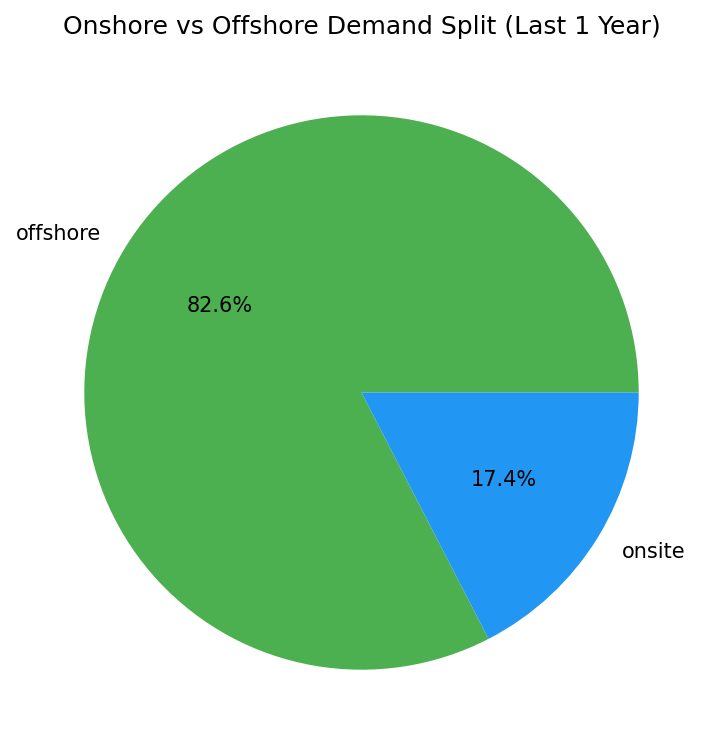

Saved plot: plots\onshore_offshore_split.png

Top Countries by Demand:
   1. India                               3,607 ( 82.5%)
   2. United States                         428 (  9.8%)
   3. Romania                                96 (  2.2%)
   4. Poland                                 42 (  1.0%)
   5. Spain                                  28 (  0.6%)
   6. United Kingdom                         26 (  0.6%)
   7. Lithuania                              26 (  0.6%)
   8. Mexico                                 22 (  0.5%)
   9. Netherlands                            21 (  0.5%)
  10. Canada                                 21 (  0.5%)
  11. Portugal                               15 (  0.3%)
  12. Brazil                                 11 (  0.3%)
  13. United Arab Emirates                    7 (  0.2%)
  14. Switzerland                             5 (  0.1%)
  15. Philippines                             4 (  0.1%)
  16. France                                  3 (  0.1%)
  17. Belgium    

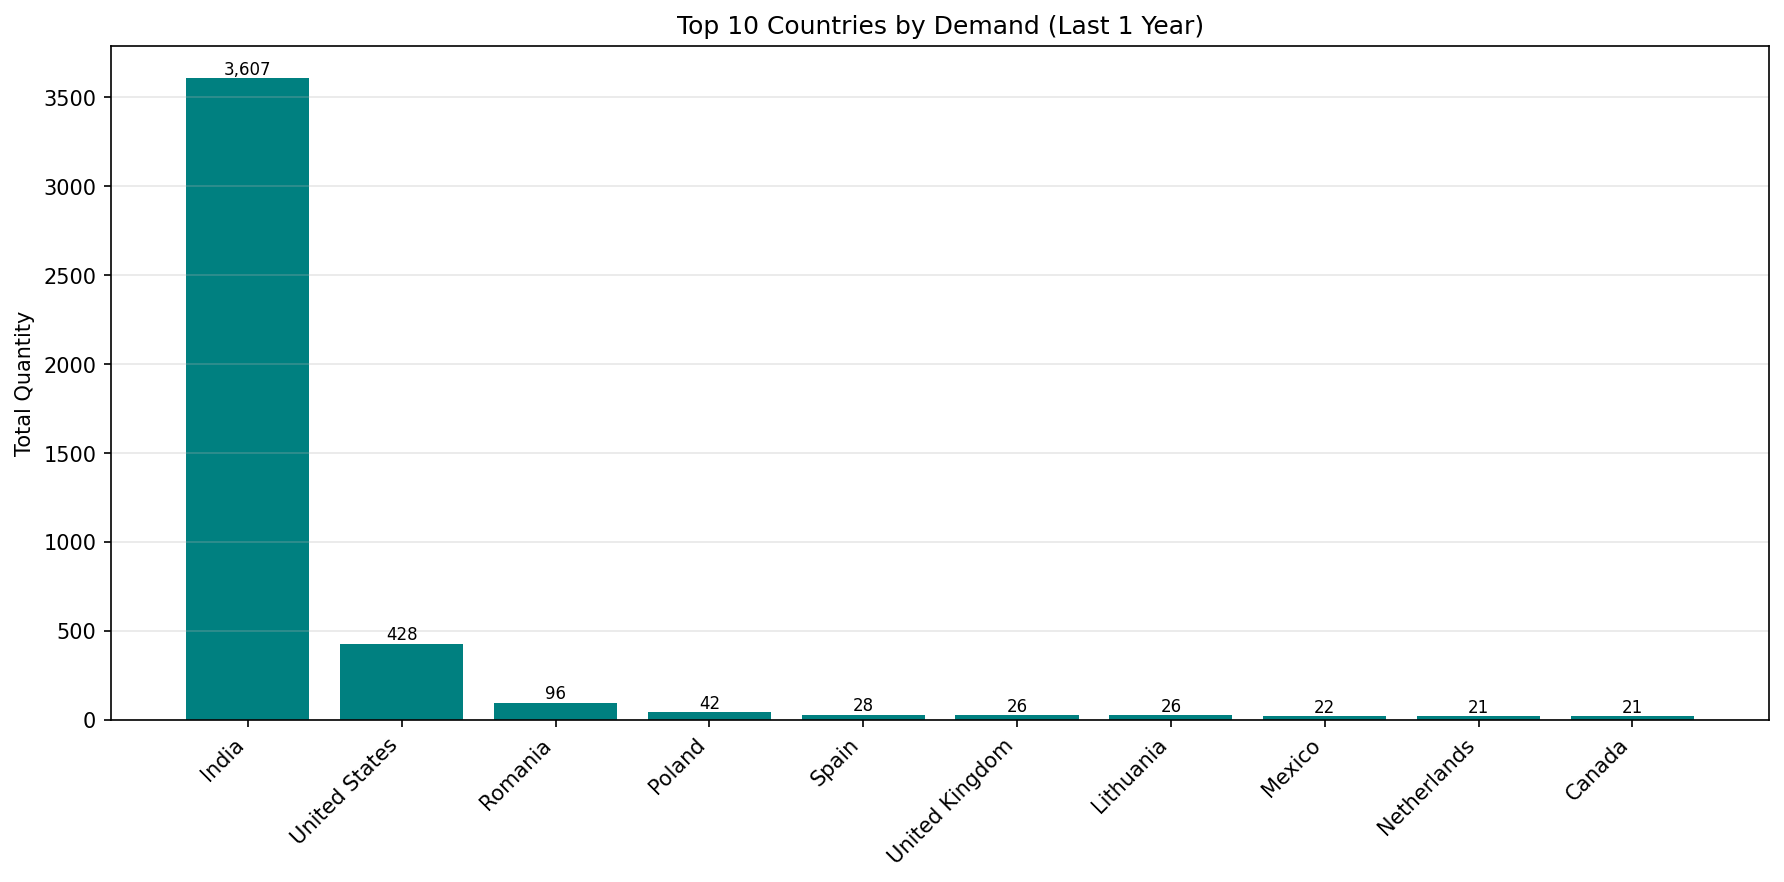

Saved plot: plots\country_wise_demand.png


In [68]:
def location_country_analysis(df):
    """Analyze Onshore/Offshore split and Country-wise demand for last 1 year."""
    print("\nLOCATION & COUNTRY DEMAND ANALYSIS")
    print("-" * 40)

    # Required columns check
    required_cols = ['Requirement Start Date', 'Quantity', 'Off/ On', 'Country']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return df

    # Cast columns
    df = df.with_columns([
        pl.col('Requirement Start Date').cast(pl.Date).alias('Requirement Start Date'),
        pl.col('Quantity').cast(pl.Float64, strict=False).alias('Quantity')
    ])

    # Filter last 1 year
    max_date = df.select(pl.col('Requirement Start Date').max()).item()
    if max_date is None:
        print("No valid dates found.")
        return df

    one_year_ago = max_date - dt.timedelta(days=365)
    df_last_year = df.filter(pl.col('Requirement Start Date') >= one_year_ago)

    if df_last_year.is_empty():
        print("No data in the last 1 year.")
        return df

    # Ensure plots folder
    os.makedirs('plots', exist_ok=True)

    # -------------------------
    # Onshore vs Offshore Split
    # -------------------------
    print("\nOnshore vs Offshore Split:")
    loc_stats = (
        df_last_year
        .group_by('Off/ On')
        .agg(pl.col('Quantity').sum().alias('total_demand'))
        .sort('total_demand', descending=True)
    ).to_pandas()

    total_loc = loc_stats['total_demand'].sum()
    for _, row in loc_stats.iterrows():
        pct = (row['total_demand'] / total_loc) * 100
        print(f"  {row['Off/ On']:15} {row['total_demand']:>10,.0f} ({pct:5.1f}%)")

    # Plot Onshore/Offshore
    plt.figure(figsize=(8, 6))
    plt.pie(loc_stats['total_demand'], labels=loc_stats['Off/ On'], autopct='%1.1f%%', colors=['#4CAF50', '#2196F3'])
    plt.title('Onshore vs Offshore Demand Split (Last 1 Year)')
    out_path_loc = os.path.join('plots', 'onshore_offshore_split.png')
    plt.savefig(out_path_loc, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(filename=out_path_loc))
    print(f"Saved plot: {out_path_loc}")

    # -------------------------
    # Country-wise Demand Split
    # -------------------------
    print("\nTop Countries by Demand:")
    country_stats = (
        df_last_year
        .group_by('Country')
        .agg(pl.col('Quantity').sum().alias('total_demand'))
        .sort('total_demand', descending=True)
    ).to_pandas()

    total_country = country_stats['total_demand'].sum()
    for i, (_, row) in enumerate(country_stats.iterrows(), start=1):
        pct = (row['total_demand'] / total_country) * 100
        print(f"  {i:2d}. {row['Country'][:30]:30} {row['total_demand']:>10,.0f} ({pct:5.1f}%)")

    # Plot Top 10 Countries
    top10 = country_stats.head(10)
    plt.figure(figsize=(12, 6))
    bars = plt.bar(top10['Country'], top10['total_demand'], color='teal')
    plt.title('Top 10 Countries by Demand (Last 1 Year)')
    plt.ylabel('Total Quantity')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height):,}", ha='center', va='bottom', fontsize=8)

    out_path_country = os.path.join('plots', 'country_wise_demand.png')
    plt.tight_layout()
    plt.savefig(out_path_country, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(filename=out_path_country))
    print(f"Saved plot: {out_path_country}")
    
    return df

df = location_country_analysis(df)

#### Grades – Grade wise total demand split before combining the GenC grades


In [69]:
def grade_wise_analysis(df):
    """Analyze total demand split by SO GRADE for last 1 year and save/show plot."""
    print("\nGRADE-WISE DEMAND ANALYSIS")
    print("-" * 40)

    # Required columns check
    required_cols = ['Requirement Start Date', 'Quantity', 'SO GRADE']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return df

    # Cast columns
    df = df.with_columns([
        pl.col('Requirement Start Date').cast(pl.Date).alias('Requirement Start Date'),
        pl.col('Quantity').cast(pl.Float64, strict=False).alias('Quantity')
    ])

    # Filter last 1 year
    max_date = df.select(pl.col('Requirement Start Date').max()).item()
    if max_date is None:
        print("No valid dates found.")
        return df

    one_year_ago = max_date - dt.timedelta(days=365)
    df_last_year = df.filter(pl.col('Requirement Start Date') >= one_year_ago)

    if df_last_year.is_empty():
        print("No data in the last 1 year.")
        return df

    # Aggregate by SO GRADE
    grade_stats = (
        df_last_year
        .group_by('SO GRADE')
        .agg(pl.col('Quantity').sum().alias('total_demand'))
        .sort('total_demand', descending=True)
    ).to_pandas()

    # Print stats
    total_sum = grade_stats['total_demand'].sum()
    print(f"Records in last 1 year: {len(df_last_year):,}")
    print("\nGrade-wise Demand:")
    for _, row in grade_stats.iterrows():
        pct = (row['total_demand'] / total_sum) * 100
        print(f"  {row['SO GRADE'][:15]:15} {row['total_demand']:>10,.0f} ({pct:5.1f}%)")

    # Ensure plots folder
    os.makedirs('plots', exist_ok=True)

    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(grade_stats['SO GRADE'], grade_stats['total_demand'], color='darkorange')
    plt.title('Total Demand by SO GRADE (Last 1 Year)')
    plt.ylabel('Total Quantity')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # Annotate bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height):,}", ha='center', va='bottom', fontsize=8)

    out_path = os.path.join('plots', 'grade_wise_analysis.png')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(filename=out_path))
    print(f"Saved plot: {out_path}")
    
    return df

# df = grade_wise_analysis(df)

### Market: 

#### Total demand for last 1 year across Markets – data without Service line, market and practice area filters

In [70]:
def market_total_demand(df):
    """Compute total demand across Markets (no time filter) and save/show plot."""
    print("\nMARKET TOTAL DEMAND")
    print("-" * 40)

    # Required columns check
    required_cols = ['Market', 'Quantity']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return df

    # Cast Quantity
    df = df.with_columns(pl.col('Quantity').cast(pl.Float64, strict=False).alias('Quantity'))

    # Aggregate by Market
    market_stats = (
        df.group_by('Market')
        .agg(pl.col('Quantity').sum().alias('total_demand'))
        .sort('total_demand', descending=True)
    ).to_pandas()

    # Print stats
    total_sum = market_stats['total_demand'].sum()
    print(f"Total Records: {len(df):,}")
    print("\nMarket Demand Split:")
    for _, row in market_stats.iterrows():
        pct = (row['total_demand'] / total_sum) * 100
        print(f"  {row['Market'][:30]:30} {row['total_demand']:>10,.0f} ({pct:5.1f}%)")

    # Ensure plots folder
    os.makedirs('plots', exist_ok=True)

    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(market_stats['Market'], market_stats['total_demand'], color='darkcyan')
    plt.title('Total Demand by Market')
    plt.ylabel('Total Quantity')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # Annotate bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height):,}", ha='center', va='bottom', fontsize=8)

    out_path = os.path.join('plots', 'market_total_demand.png')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(filename=out_path))
    print(f"Saved plot: {out_path}")
    
    return df

# df = market_total_demand(df)

#### BU level demand split: Total demand for last 1 year across different BUs


BU-LEVEL DEMAND ANALYSIS
----------------------------------------
Records in last 1 year: 4,374

BU Demand Split:
  Banking & Capital Markets - NA      1,398 ( 32.0%)
  Financial Services & FinTech -        409 (  9.4%)
  Payer BU                              308 (  7.0%)
  ML-NA                                 304 (  7.0%)
  Provider BU                           219 (  5.0%)
  BFS-UK                                181 (  4.1%)
  CommsMedia-NA                         174 (  4.0%)
  Consumer NA                           153 (  3.5%)
  Netherlands                           144 (  3.3%)
  Technology-NA                         129 (  2.9%)
  Insurance 1                           129 (  2.9%)
  Insurance 2                           122 (  2.8%)
  CommsMedia-UK                          72 (  1.6%)
  Insurance-UK                           71 (  1.6%)
  Retail NA                              68 (  1.6%)
  Middle East                            67 (  1.5%)
  Life Sciences-NA                   

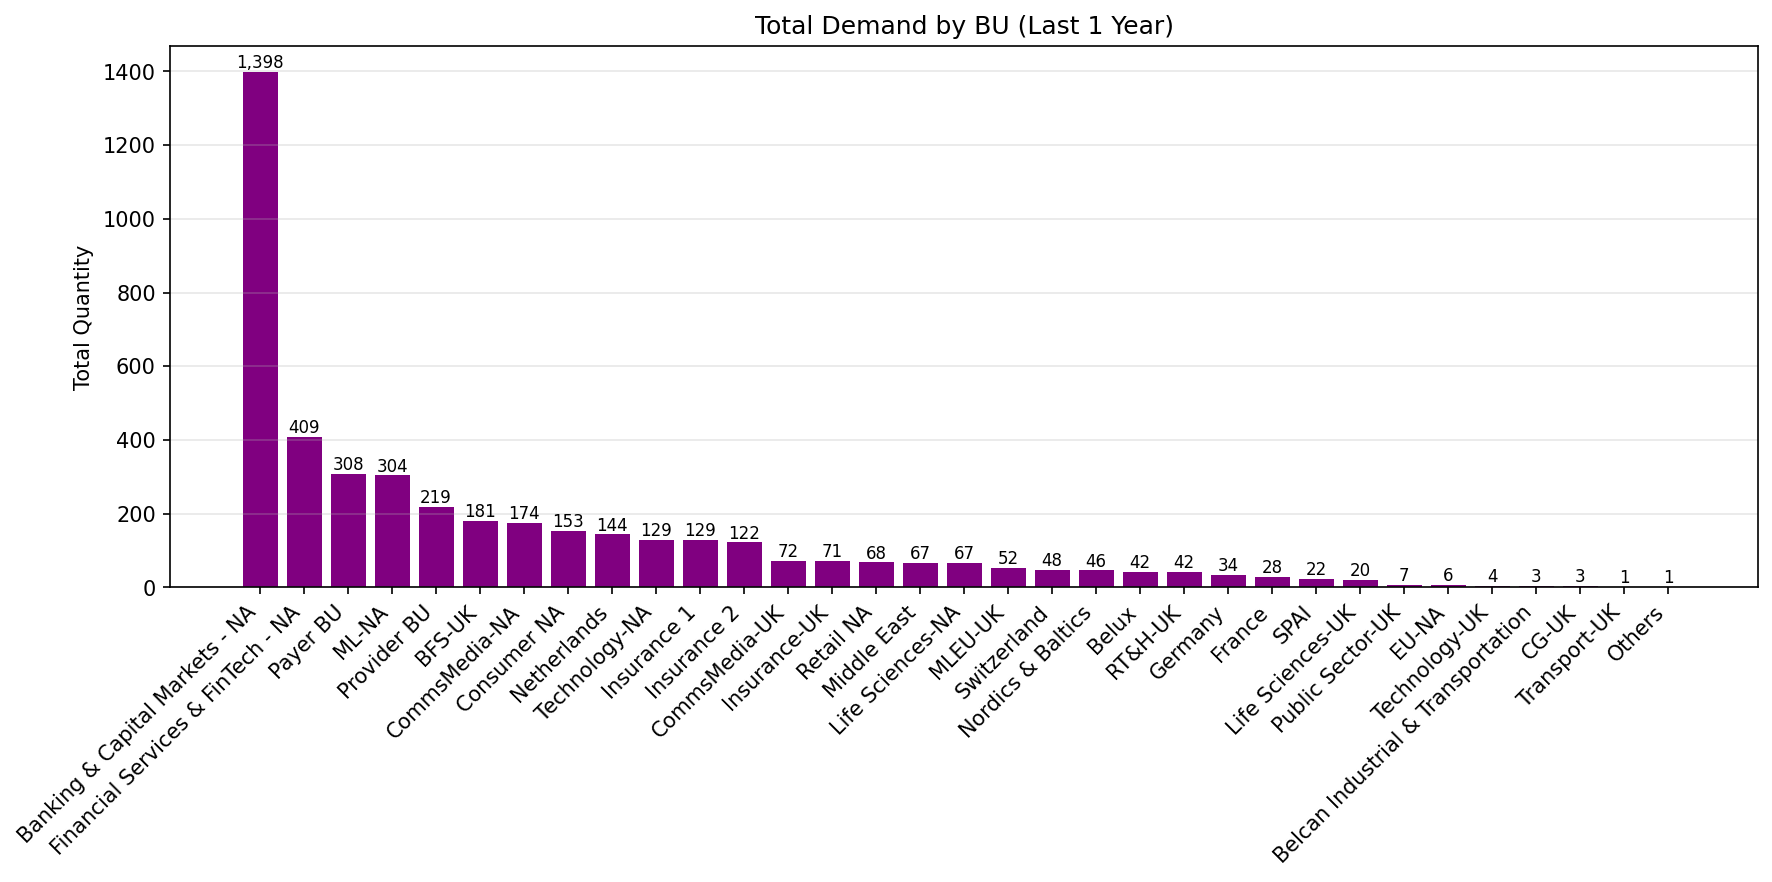

Saved plot: plots\bu_level_analysis.png


In [71]:
def bu_level_analysis(df):
    """Analyze total demand by BU for last 1 year and save/show plot."""
    print("\nBU-LEVEL DEMAND ANALYSIS")
    print("-" * 40)

    # Required columns check
    required_cols = ['Requirement Start Date', 'Quantity', 'BU']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return df

    # Cast columns
    df = df.with_columns([
        pl.col('Requirement Start Date').cast(pl.Date).alias('Requirement Start Date'),
        pl.col('Quantity').cast(pl.Float64, strict=False).alias('Quantity')
    ])

    # Filter last 1 year
    max_date = df.select(pl.col('Requirement Start Date').max()).item()
    if max_date is None:
        print("No valid dates found.")
        return df

    one_year_ago = max_date - dt.timedelta(days=365)
    df_last_year = df.filter(pl.col('Requirement Start Date') >= one_year_ago)

    if df_last_year.is_empty():
        print("No data in the last 1 year.")
        return df

    # Aggregate by BU
    bu_stats = (
        df_last_year
        .group_by('BU')
        .agg(pl.col('Quantity').sum().alias('total_demand'))
        .sort('total_demand', descending=True)
    ).to_pandas()

    # Print stats
    total_sum = bu_stats['total_demand'].sum()
    print(f"Records in last 1 year: {len(df_last_year):,}")
    print("\nBU Demand Split:")
    for _, row in bu_stats.iterrows():
        pct = (row['total_demand'] / total_sum) * 100
        print(f"  {row['BU'][:30]:30} {row['total_demand']:>10,.0f} ({pct:5.1f}%)")

    # Ensure plots folder
    os.makedirs('plots', exist_ok=True)

    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(bu_stats['BU'], bu_stats['total_demand'], color='purple')
    plt.title('Total Demand by BU (Last 1 Year)')
    plt.ylabel('Total Quantity')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # Annotate bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f"{int(height):,}", ha='center', va='bottom', fontsize=8)

    out_path = os.path.join('plots', 'bu_level_analysis.png')
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(filename=out_path))
    print(f"Saved plot: {out_path}")
    
    return df

df = bu_level_analysis(df)

#### BU Trends (Excel with Mean, Median, STD for Time Series)

In [72]:
def bu_trends_to_excel(df, output_file='plots/bu_trends.xlsx'):
    """Generate BU trends (mean, median, std) for time series and save to Excel."""
    print("\nBU TRENDS ANALYSIS")
    print("-" * 40)

    # Required columns check
    required_cols = ['Requirement Start Date', 'Quantity', 'BU']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return df

    # Cast columns
    df = df.with_columns([
        pl.col('Requirement Start Date').cast(pl.Date).alias('Requirement Start Date'),
        pl.col('Quantity').cast(pl.Float64, strict=False).alias('Quantity')
    ])

    # Filter last 1 year
    max_date = df.select(pl.col('Requirement Start Date').max()).item()
    if max_date is None:
        print("No valid dates found.")
        return df

    one_year_ago = max_date - dt.timedelta(days=365)
    df_last_year = df.filter(pl.col('Requirement Start Date') >= one_year_ago)

    if df_last_year.is_empty():
        print("No data in the last 1 year.")
        return df

    # Truncate to month start
    df_last_year = df_last_year.with_columns(
        pl.col('Requirement Start Date').dt.truncate('1mo').alias('month_start')
    )

    # Group by BU and month
    grouped = (
        df_last_year
        .group_by(['BU', 'month_start'])
        .agg(pl.col('Quantity').sum().alias('total_quantity'))
        .sort(['BU', 'month_start'])
    ).to_pandas()

    # Create Excel with stats per BU
    os.makedirs('plots', exist_ok=True)
    with pd.ExcelWriter(output_file) as writer:
        for bu in grouped['BU'].unique():
            bu_data = grouped[grouped['BU'] == bu].copy()
            bu_data['month_start'] = pd.to_datetime(bu_data['month_start'])
            bu_data.set_index('month_start', inplace=True)

            # Compute stats
            mean_val = bu_data['total_quantity'].mean()
            median_val = bu_data['total_quantity'].median()
            std_val = bu_data['total_quantity'].std()

            # Add stats row
            stats_row = pd.DataFrame({
                'mean': [mean_val],
                'median': [median_val],
                'std': [std_val]
            })

            # Write BU data and stats
            bu_data.to_excel(writer, sheet_name=f"{bu[:30]}_data")
            stats_row.to_excel(writer, sheet_name=f"{bu[:30]}_stats")

    print(f"Excel saved: {output_file}")
    
    return df

df = bu_trends_to_excel(df)


BU TRENDS ANALYSIS
----------------------------------------
Excel saved: plots/bu_trends.xlsx


### Finding Correlations between cols

In [73]:
def monthly_feature_corr(
    df,
    mode="focused",                  # "focused" or "full"
    output_file="plots/monthly_corr.png",
    max_cat_levels=40,
    top_n_plot=40,
    max_skill_levels=200
):
    # Basic checks
    need_cols = ["Quantity", "Requirement Start Date"]
    missing = [c for c in need_cols if c not in df.columns]
    if missing:
        print(f"Missing required columns: {missing}")
        return pl.DataFrame([])

    # Cast & clean
    df = df.with_columns([
        pl.col("Quantity").cast(pl.Float64, strict=False),
        pl.col("Requirement Start Date").cast(pl.Date, strict=False),
    ]).filter(
        pl.col("Requirement Start Date").is_not_null() & pl.col("Quantity").is_not_null()
    )
    if df.is_empty():
        print("No valid rows after casting/filtering.")
        return pl.DataFrame([])

    # Month key
    df = df.with_columns(pl.col("Requirement Start Date").dt.truncate("1mo").alias("month_start"))

    # Choose columns based on mode
    if mode == "focused":
        core_cat = [c for c in ["BU", "Project Billability Type", "Off/ On", "Country", "SO GRADE"] if c in df.columns]
        skills_col = "Technical Skills Required" if "Technical Skills Required" in df.columns else None
        date_cols = ["Requirement Start Date"]  # for extra date features (optional)
    else:
        # FULL mode: discover all categorical/date/numeric automatically
        skills_col = "Technical Skills Required" if "Technical Skills Required" in df.columns else None
        core_cat = [c for c, t in zip(df.columns, df.dtypes) if t == pl.Utf8 and c != skills_col]
        date_cols = [c for c, t in zip(df.columns, df.dtypes) if t in (pl.Date, pl.Datetime)]

    # Group keys
    group_cols = ["month_start"] + core_cat

    # Aggregate monthly totals (+ skills if present)
    agg_list = [pl.col("Quantity").sum().alias("monthly_quantity")]
    if skills_col:
        agg_list.append(pl.col(skills_col).alias("skills_list"))
    monthly = df.group_by(group_cols).agg(agg_list).sort(group_cols)
    if monthly.is_empty():
        print("Monthly aggregation produced no rows.")
        return pl.DataFrame([])

    # Skills concat per group
    if skills_col:
        monthly = monthly.with_columns(pl.col("skills_list").list.join(",").alias("skills_concat"))

    # Date features from month_start (always present)
    feats = [
        pl.col("month_start").dt.month().cast(pl.Int32).alias("month__num"),
        pl.col("month_start").dt.year().cast(pl.Int32).alias("month__year"),
        pl.col("month_start").dt.quarter().cast(pl.Int32).alias("month__quarter"),
    ]
    mnum = pl.col("month_start").dt.month().cast(pl.Float64)
    feats += [
        (np.sin(2 * np.pi * (mnum - 1) / 12)).alias("month__sin"),
        (np.cos(2 * np.pi * (mnum - 1) / 12)).alias("month__cos"),
    ]
    min_m = monthly.select(pl.col("month_start").min()).item()
    if min_m is not None:
        feats += [
            (pl.col("month_start").cast(pl.Int64) - pl.lit(min_m).cast(pl.Int64)).cast(pl.Int32).alias("month__age_days"),
            ((pl.col("month_start").cast(pl.Int64) - pl.lit(min_m).cast(pl.Int64)) / 30).cast(pl.Float64).alias("month__age_months"),
        ]
    monthly = monthly.with_columns(feats)

    # Extra date features in FULL mode (from any date/datetime columns present)
    if mode == "full" and date_cols:
        extra_feats = []
        for c in date_cols:
            if c == "month_start":
                continue
            extra_feats += [
                pl.col(c).dt.month().cast(pl.Int32).alias(f"{c}__month"),
                pl.col(c).dt.year().cast(pl.Int32).alias(f"{c}__year"),
                pl.col(c).dt.week().cast(pl.Int32).alias(f"{c}__week"),
                pl.col(c).dt.ordinal_day().cast(pl.Int32).alias(f"{c}__dayofyear"),
            ]
            cm = pl.col(c).dt.month().cast(pl.Float64)
            extra_feats += [
                (np.sin(2 * np.pi * (cm - 1) / 12)).alias(f"{c}__month_sin"),
                (np.cos(2 * np.pi * (cm - 1) / 12)).alias(f"{c}__month_cos"),
            ]
        monthly = monthly.with_columns(extra_feats)

    # Skills impact encoding
    if skills_col:
        skills_tokens = (
            monthly
            .with_columns(
                pl.when(pl.col("skills_concat").is_not_null())
                .then(pl.col("skills_concat").str.split(","))
                .otherwise(pl.lit([]))
                .alias("skills_tokens")
            )
            .with_columns(
                pl.col("skills_tokens").list.eval(
                    pl.element().str.strip_chars().str.to_lowercase()
                ).alias("skills_tokens")
            )
            .select([*group_cols, "monthly_quantity", "skills_tokens"])
            .explode("skills_tokens")
            .filter(pl.col("skills_tokens").is_not_null() & (pl.col("skills_tokens") != ""))
        )
        if skills_tokens.is_empty():
            monthly = monthly.with_columns([pl.lit(0.0).alias("skills_te_mean"), pl.lit(0).alias("skills_count")])
        else:
            skill_stats = (
                skills_tokens.group_by("skills_tokens")
                .agg([pl.len().alias("cnt"), pl.col("monthly_quantity").mean().alias("skill_te")])
                .sort("cnt", descending=True)
            )
            top_skills = set(skill_stats.head(max_skill_levels)["skills_tokens"].to_list())
            skill_stats_top = skill_stats.filter(pl.col("skills_tokens").is_in(list(top_skills)))
            skills_scored = (
                skills_tokens.join(skill_stats_top, on="skills_tokens", how="left")
                .filter(pl.col("skill_te").is_not_null())
            )
            skills_agg = (
                skills_scored.group_by(group_cols)
                .agg([pl.col("skill_te").mean().alias("skills_te_mean"), pl.len().alias("skills_count")])
            )
            monthly = monthly.join(skills_agg, on=group_cols, how="left").with_columns([
                pl.col("skills_te_mean").fill_null(0.0),
                pl.col("skills_count").fill_null(0),
            ])

    # Target-mean encoding for discovered categoricals
    target = "monthly_quantity"
    for c in core_cat:
        counts = monthly.group_by(c).agg(pl.len().alias("cnt")).sort("cnt", descending=True)
        top_levels = counts.head(max_cat_levels)[c].to_list()
        monthly = monthly.with_columns(
            pl.when(pl.col(c).is_in(top_levels)).then(pl.col(c)).otherwise(pl.lit("__OTHER__")).alias(f"{c}__cap")
        )
        te_map = monthly.group_by(f"{c}__cap").agg(pl.col(target).mean().alias(f"{c}__te"))
        monthly = monthly.join(te_map, on=f"{c}__cap", how="left")

    # Feature selection
    feature_cols = [
        "month__num", "month__year", "month__quarter", "month__sin", "month__cos",
        "month__age_days", "month__age_months",
    ]
    if skills_col:
        feature_cols += ["skills_te_mean", "skills_count"]
    feature_cols += [f"{c}__te" for c in core_cat]

    # In FULL mode include all additional numeric columns already present
    if mode == "full":
        extra_numeric = [c for c, t in zip(monthly.columns, monthly.dtypes)
                         if t in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                                  pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                                  pl.Float32, pl.Float64)]
        extra_numeric = [c for c in extra_numeric if c not in feature_cols + [target]]
        feature_cols += extra_numeric

    # Keep only existing cols
    feature_cols = [c for c in feature_cols if c in monthly.columns]
    X = monthly.select(feature_cols + [pl.col(target)])

    # Correlations via pandas
    pdf = X.to_pandas().copy()
    pdf = pdf.dropna(axis=1, how="all")
    nunique = pdf.nunique()
    constant_cols = [c for c in nunique.index.tolist() if nunique[c] <= 1 and c != target]
    pdf = pdf.drop(columns=constant_cols)

    y = pdf[target]
    feat_cols = [c for c in pdf.columns if c != target]
    if len(feat_cols) == 0:
        print("No usable features after monthly aggregation.")
        return pl.DataFrame([])

    pearson, spearman = {}, {}
    for c in feat_cols:
        s = pd.to_numeric(pdf[c], errors="coerce")
        pearson[c] = s.corr(y, method="pearson")
        spearman[c] = s.corr(y, method="spearman")

    corr_df = pd.DataFrame({
        "feature": feat_cols,
        "pearson_corr": [pearson[c] for c in feat_cols],
        "spearman_corr": [spearman[c] for c in feat_cols],
    })
    corr_df["abs_pearson"] = corr_df["pearson_corr"].abs()
    corr_sorted = corr_df.sort_values("abs_pearson", ascending=False)

    # Heatmap — readable formatting
    top_feats = corr_sorted.head(top_n_plot)["feature"].tolist()
    plot_cols = [target] + top_feats
    corr_matrix = pdf[plot_cols].corr(method="pearson").fillna(0)

    n = len(plot_cols)
    size = max(12, min(30, 0.8 * n))
    plt.figure(figsize=(size, size), dpi=220)
    ax = sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        cbar=True,
        square=True,
        linewidths=0.6,
        linecolor="white",
        annot_kws={"size": 10, "color": "black"},
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
    ax.set_title("Monthly Correlation Heatmap (engineered features)", fontsize=13, pad=14)
    plt.tight_layout()
    os.makedirs(os.path.dirname(output_file) or ".", exist_ok=True)
    plt.savefig(output_file, dpi=220, bbox_inches="tight")
    plt.close()
    display(Image(filename=output_file))

    print("Top monthly features by |Pearson| correlation with target (monthly_quantity):")
    print(corr_sorted.head(20).to_string(index=False))

    return pl.from_pandas(corr_sorted)


In [74]:
# Quantity, Requirement Start Date, BU, Project Billability Type, Off/ On,
# Country, SO GRADE, Technical Skills Required

# # Focused set (your key cols only)
# corr_focused = monthly_feature_corr(df, mode="focused", output_file="plots/monthly_corr_focused.png")

# # Full scan (all categorical/date/numeric available in df)
# df_full = pl.read_csv("data/DFC_YTD.csv")  # reload original data to avoid prior filtering
# corr_full = monthly_feature_corr(df, mode="full", output_file="plots/monthly_corr_full.png")

In [75]:
#BU	Project Billability Type	Quantity	SO Submission Date	Off/ On	Country	Requirement Start Date	SO GRADE	Technical Skills Required
